If you are using Google Colab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -r /content/drive/MyDrive/path/to/your/project/requirements.txt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.7 MB/s eta 0:00:00


Run 3RFold with defined configuration

In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/path/to/your/project/')

In [ ]:
%cd /content/drive/MyDrive/path/to/your/project/
!python run_3RFold.py --config configs/default.yaml

/content/drive/MyDrive/Foldv
Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})
Loading cached embeddings from kb_embeddings_rnafm_len256.pt...
Dataset size: 1600
KB embeddings shape: torch.Size([200, 640])
Training DSR...
Epoch 0 Loss 0.2146
Epoch 20 Loss 0.1981
Epoch 40 Loss 0.1924
Building FAISS index...
Query embedding shape: torch.Size([1, 640])
Neighbor families: ['16S_rRNA', '16S_rRNA', '16S_rRNA', '16S_rRNA', '16S_rRNA']
{'pred_structure': '...........................................................................................................................................................................................................................................(((((....((((((......................................(((....)))............((((..(((.............................((((.(((((((...............................((..(((.((.............)).)))..))...((((((.....)))))).............................

# Run benchmark and save results

In [ ]:
!python experiments/run_benchmark.py

/usr/local/lib/python3.12/dist-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(
Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})
Downloading: "https://proj.cse.cuhk.edu.hk/rnafm/api/download?filename=RNA-FM_pretrained.pth" to /root/.cache/torch/hub/checkpoints/RNA-FM_pretrained.pth
100% 1.11G/1.11G [12:08<00:00, 1.64MB/s]
Loading cached embeddings from results/kb_embeddings_rnafm_len256.pt...

=== Benchmark summary ===
                  method   n   f1_mean  ...  ppv_mean  purity_mean  runtime_mean
0  rnafm_faiss_guided_k5  50  0.576590  ...  0.621680        0.864      1.005329
1            vienna_only  50  0.416877  ...  0.40

# Run ablation and save results

In [ ]:
!python experiments/run_ablation.py

/usr/local/lib/python3.12/dist-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(
Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})

Running: vienna_only

Running: rnafm_faiss_no_guidance_k5
Loading cached embeddings from results/kb_embeddings_rnafm_len256.pt...

Running: rnafm_faiss_guided_k1
Loading cached embeddings from results/kb_embeddings_rnafm_len256.pt...

Running: rnafm_faiss_guided_k3
Loading cached embeddings from results/kb_embeddings_rnafm_len256.pt...

Running: rnafm_faiss_guided_k5
Loading cached embeddings from results/kb_embeddings_rnafm_len256.pt...

Running: rnafm_faiss_guided_k7
Loading cached embeddings from

# Plotting results

In [ ]:
from visualisation.performance_plots import *
from visualisation.family_plots import *
from visualisation.retrieval_plots import *
from visualisation.improvement_plots import *


plot_f1_by_method("results/ablation_results.csv")
plot_k_sweep("results/ablation_results.csv")
plot_violin_f1("results/ablation_results.csv")
plot_family_f1("results/ablation_results.csv")
plot_purity_vs_f1("results/ablation_results.csv")
plot_similarity_vs_f1("results/ablation_results.csv")
plot_improvement_over_baseline("results/ablation_results.csv")
plot_improvement_vs_purity("results/ablation_results.csv")

plot_f1_by_method("results/ablation_results.csv")
plot_k_sweep("results/ablation_results.csv")
plot_violin_f1("results/ablation_results.csv")
plot_family_f1("results/ablation_results.csv")
plot_purity_vs_f1("results/ablation_results.csv")
plot_similarity_vs_f1("results/ablation_results.csv")

plot_f1_by_method("results/ablation_results.csv")
plot_k_sweep("results/ablation_results.csv")
plot_violin_f1("results/ablation_results.csv")

plot_family_f1("results/ablation_results.csv")

plot_purity_vs_f1("results/ablation_results.csv")
plot_similarity_vs_f1("results/ablation_results.csv")

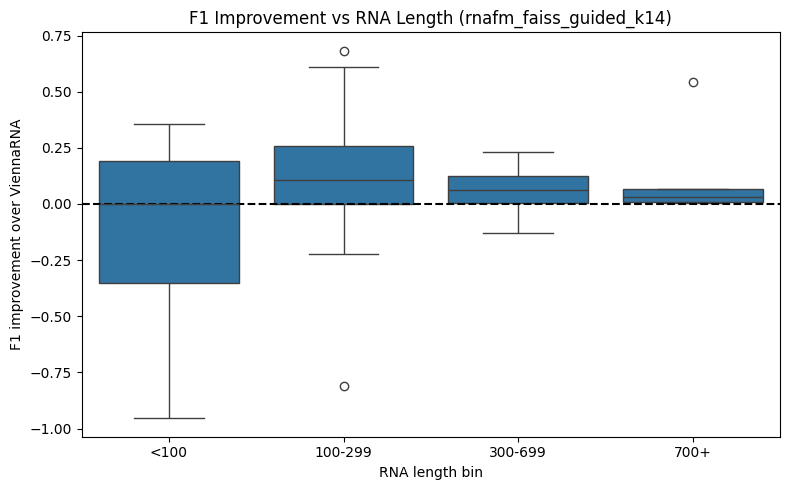

In [ ]:
import importlib
import visualisation.length_plots as lp

importlib.reload(lp)

lp.plot_improvement_vs_length("results/ablation_results.csv")

# Run LOFO benchmark

In [ ]:
!python -u experiments/run_lofo_benchmark.py

/content/drive/MyDrive/Foldv
/usr/local/lib/python3.12/dist-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(
Building dataset...
Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})
Dataset built: 1600
Families: ['16S_rRNA', '5S_rRNA', 'RNaseP', 'RfamFamily', 'SRP', 'group_I_intron', 'tRNA', 'tmRNA']
Loading full cached embeddings from results/kb_embeddings_rnafm_len256_full.pt...
All embeddings shape: torch.Size([1600, 640])

LOFO: 16S_rRNA
KB size: 1400 Test size: 200
KB embedding shape: torch.Size([1400, 640])

LOFO: 5S_rRNA
KB size: 1400 Test size: 200
KB embedding shape: torch.Size([1400, 640])

LOFO: RNaseP
KB size: 1400 Tes

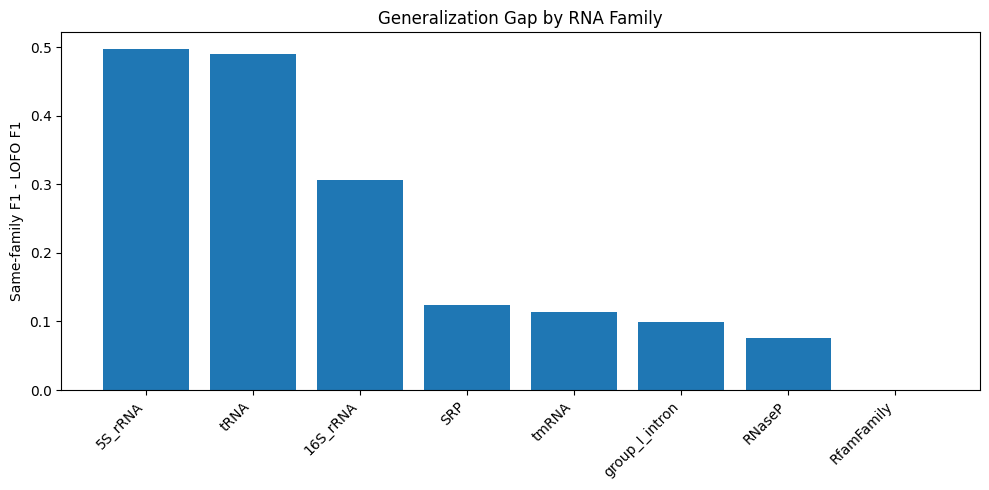

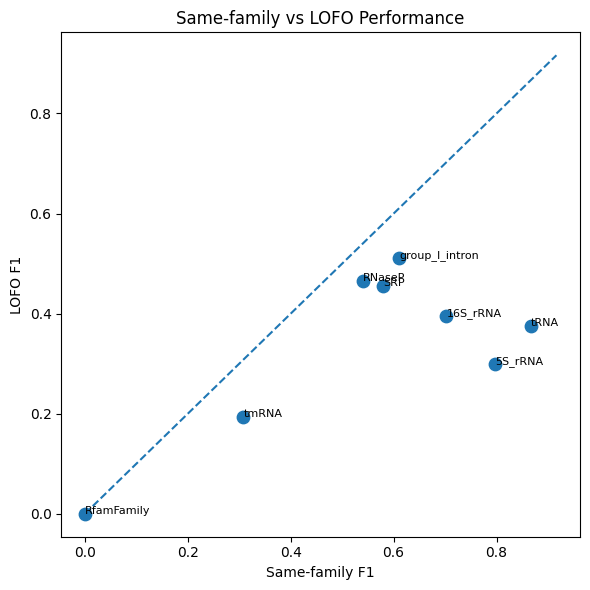

In [ ]:
from evaluation.generalization_gap import compute_generalization_gap
from visualisation.generalization_plots import plot_generalization_gap, plot_same_vs_lofo

compute_generalization_gap()
plot_generalization_gap()
plot_same_vs_lofo()

In [ ]:
from evaluation.failure_analysis import retrieval_failure_analysis
failure_df = retrieval_failure_analysis()
print(failure_df.head())

                                 query_id      family  length  \
0                       tRNA-tdbD00005436        tRNA      75   
1     RfamFamily_URS0000D68DE1_12908/1-49  RfamFamily      49   
2    RfamFamily_URS0000D6C504_12908/1-170  RfamFamily     170   
3  SRP-long_bacterial-Clos.ther._CP000568         SRP     175   
4       RfamFamily_AAIY01141103.1/124-267  RfamFamily     144   

                   method retrieval_type  use_guidance guidance_mode  use_dsr  \
0  rnafm_faiss_guided_k14          faiss             1     consensus        0   
1  rnafm_faiss_guided_k14          faiss             1     consensus        0   
2  rnafm_faiss_guided_k14          faiss             1     consensus        0   
3  rnafm_faiss_guided_k14          faiss             1     consensus        0   
4  rnafm_faiss_guided_k14          faiss             1     consensus        0   

    k                                  neighbor_families  ...  \
0  14  tRNA|tRNA|tRNA|tRNA|tRNA|tRNA|tRNA|tRNA|tRNA|t... 

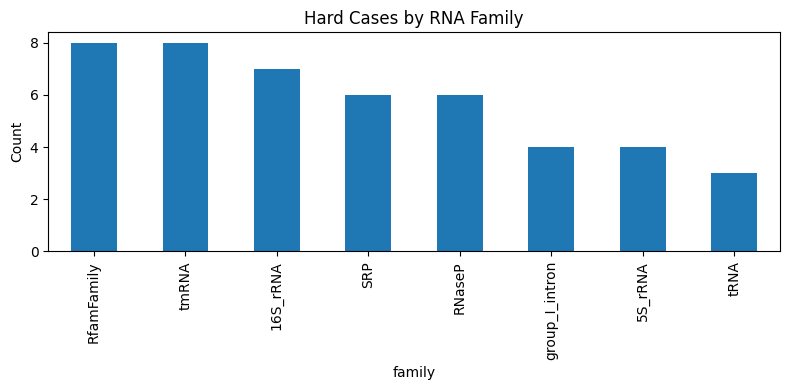

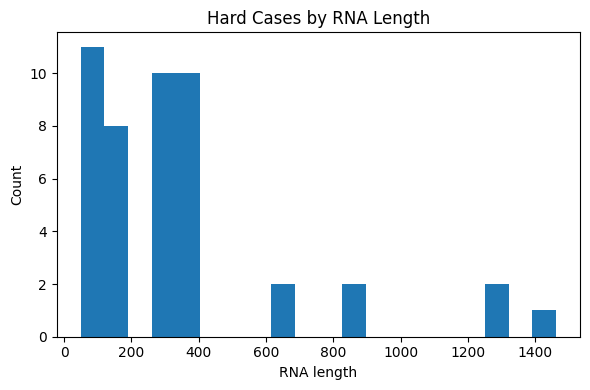

In [ ]:
from visualisation.hard_case_plots import plot_hard_cases_by_family, plot_hard_cases_by_length

plot_hard_cases_by_family()
plot_hard_cases_by_length()

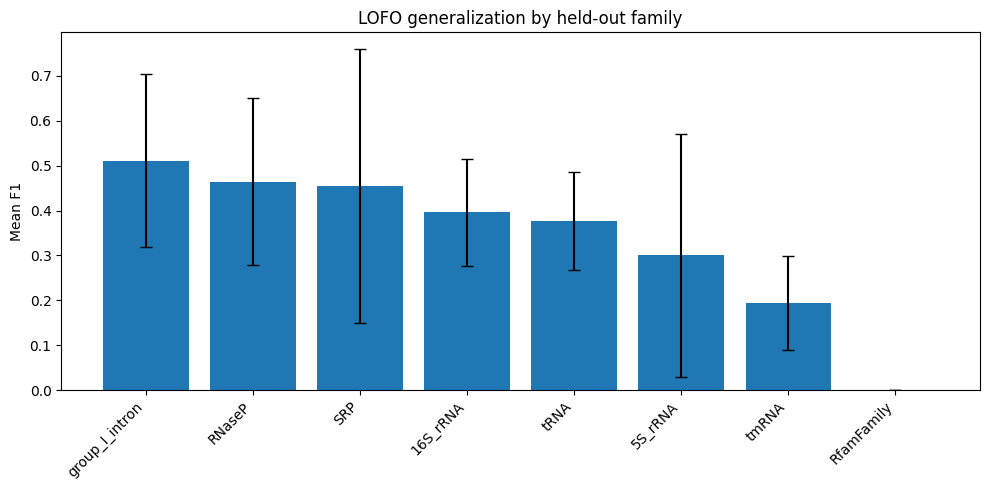

In [ ]:
from visualisation.lofo_plots import plot_lofo_f1
plot_lofo_f1()

# Run umap embedding

In [ ]:
!python experiments/run_embedding_umap.py

2026-03-13 00:42:19.356968: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-13 00:42:19.883844: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-13 00:42:20.176686: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773362540.553881   35540 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773362540.653138   35540 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773362541.406898   35540 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

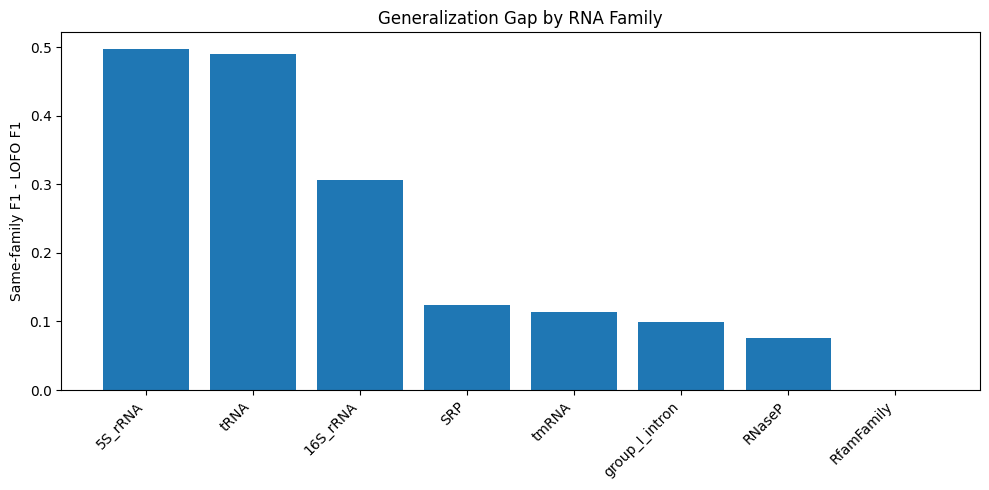

In [ ]:
from evaluation.generalization_gap import compute_generalization_gap
from visualisation.generalization_plots import plot_generalization_gap

compute_generalization_gap()
plot_generalization_gap()

Run DSR Ablation

In [ ]:
!python experiments/run_dsr_ablation.py

PROJECT_ROOT: /content/drive/MyDrive/Foldv
RESULTS_DIR: /content/drive/MyDrive/Foldv/results
OUTPUT CSV: /content/drive/MyDrive/Foldv/results/dsr_ablation.csv
EMBEDDINGS PATH: /content/drive/MyDrive/Foldv/results/kb_embeddings_rnafm_len256_full.pt
Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})
Running DSR query 1/50
Epoch 0 Loss 0.2465
Running DSR query 2/50
Epoch 0 Loss 0.2525
Running DSR query 3/50
Epoch 0 Loss 0.2450
Running DSR query 4/50
Epoch 0 Loss 0.2415
Running DSR query 5/50
Epoch 0 Loss 0.2435
Running DSR query 6/50
Epoch 0 Loss 0.2458
Running DSR query 7/50
Epoch 0 Loss 0.2441
Running DSR query 8/50
Epoch 0 Loss 0.2460
Running DSR query 9/50
Epoch 0 Loss 0.2488
Running DSR query 10/50
Epoch 0 Loss 0.2465
Running DSR query 11/50
Epoch 0 Loss 0.2384
Running DSR query 12/50
Epoch 0 Loss 0.2496
Running DSR query 13/50
Epoch 0 Loss 0.2434
Running DSR query 14/50
Epoch 0 Loss 0.2422
Running DSR query 15

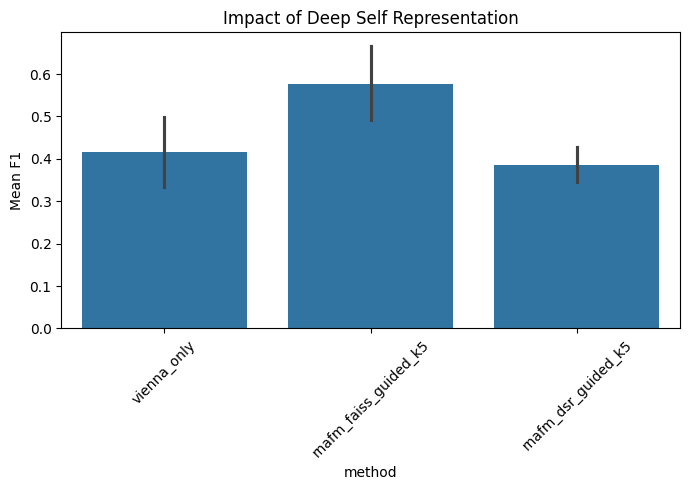

In [ ]:
from visualisation.dsr_plots import plot_dsr_comparison
plot_dsr_comparison()

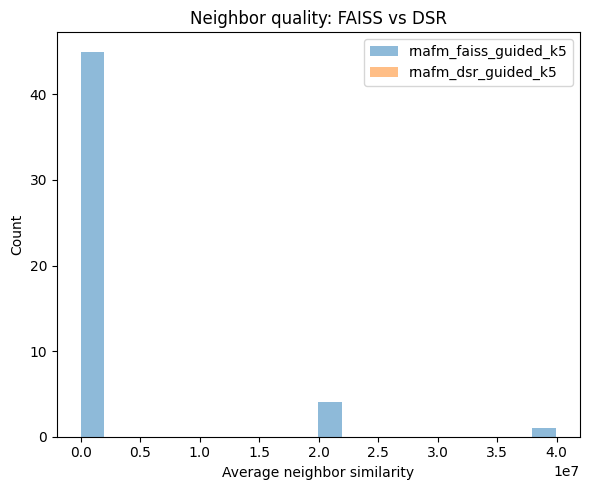

In [ ]:
from visualisation.dsr_retrieval_plots import plot_neighbor_quality
plot_neighbor_quality()

# Run DSR global Ablation

In [ ]:
!python experiments/run_dsr_global_ablation.py

PROJECT_ROOT: /content/drive/MyDrive/Foldv
RESULTS_DIR: /content/drive/MyDrive/Foldv/results
OUTPUT CSV: /content/drive/MyDrive/Foldv/results/dsr_global_ablation.csv
EMBEDDINGS PATH: /content/drive/MyDrive/Foldv/results/kb_embeddings_rnafm_len256_full.pt
README.md: 4.11kB [00:00, 1.51MB/s]
train.parquet: 100% 1.70M/1.70M [00:00<00:00, 1.86MB/s]
Generating train split: 100% 37149/37149 [00:00<00:00, 83914.18 examples/s]
Map: 100% 37149/37149 [00:04<00:00, 8501.19 examples/s]
README.md: 4.01kB [00:00, 5.31MB/s]
test.parquet: 100% 283k/283k [00:00<00:00, 703kB/s] 
Generating test split: 100% 3975/3975 [00:00<00:00, 242077.45 examples/s]
Map: 100% 3975/3975 [00:00<00:00, 12028.27 examples/s]
README.md: 4.11kB [00:00, 5.63MB/s]
train.parquet: 100% 761k/761k [00:00<00:00, 1.89MB/s]
Generating train split: 100% 25425/25425 [00:00<00:00, 690142.83 examples/s]
Map: 100% 25425/25425 [00:03<00:00, 7651.83 examples/s]
README.md: 4.11kB [00:00, 5.16MB/s]
train.parquet: 100% 916k/916k [00:00<00:00, 

In [ ]:
!python experiments/run_dsr_global_all.py

PROJECT_ROOT: /content/drive/MyDrive/Foldv
RESULTS_DIR: /content/drive/MyDrive/Foldv/results
OUTPUT CSV: /content/drive/MyDrive/Foldv/results/dsr_global_all_results.csv
Z PATH: /content/drive/MyDrive/Foldv/results/dsr_global_Z.pt
EMBEDDINGS PATH: /content/drive/MyDrive/Foldv/results/kb_embeddings_rnafm_len256_full.pt
Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})
Dataset size: 1600
Embeddings shape: torch.Size([1600, 640])
Training global DSR on all embeddings...
Epoch 1/20 Loss 0.2466
Epoch 20/20 Loss 0.5331
Saved DSR matrix to: /content/drive/MyDrive/Foldv/results/dsr_global_Z.pt
Evaluating query 1/1600
Evaluating query 100/1600
Evaluating query 200/1600
Evaluating query 300/1600
Evaluating query 400/1600
Evaluating query 500/1600
Evaluating query 600/1600
Evaluating query 700/1600
Evaluating query 800/1600
Evaluating query 900/1600
Evaluating query 1000/1600
Evaluating query 1100/1600
Evaluating query 1200

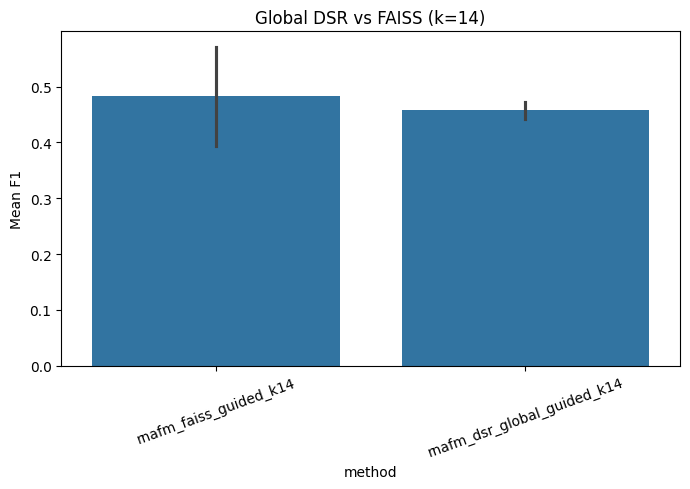

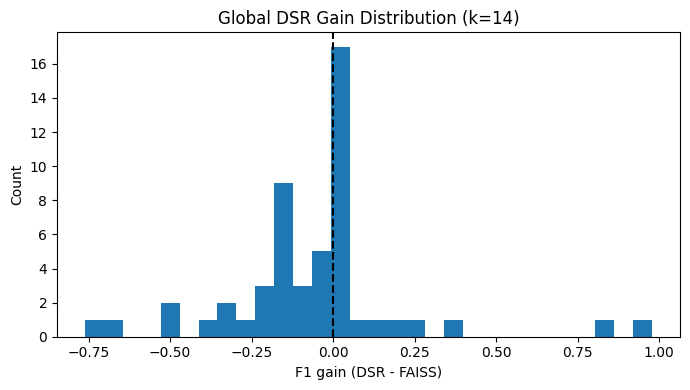

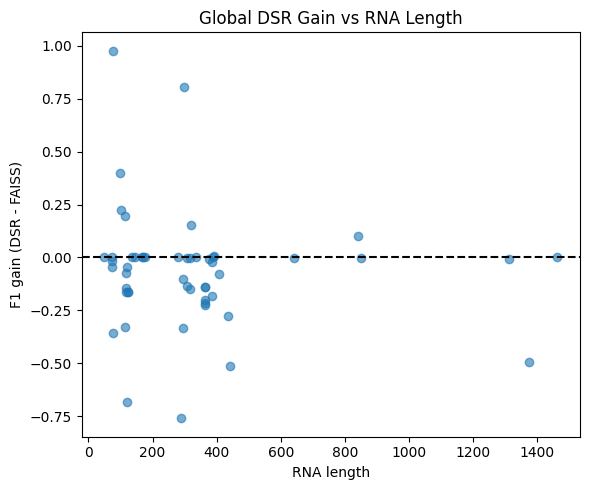

In [ ]:
from visualisation.dsr_all_plots import (
    plot_dsr_all_vs_faiss_k14,
    plot_dsr_all_gain_distribution,
    plot_dsr_all_gain_vs_length,
)

plot_dsr_all_vs_faiss_k14()
plot_dsr_all_gain_distribution()
plot_dsr_all_gain_vs_length()

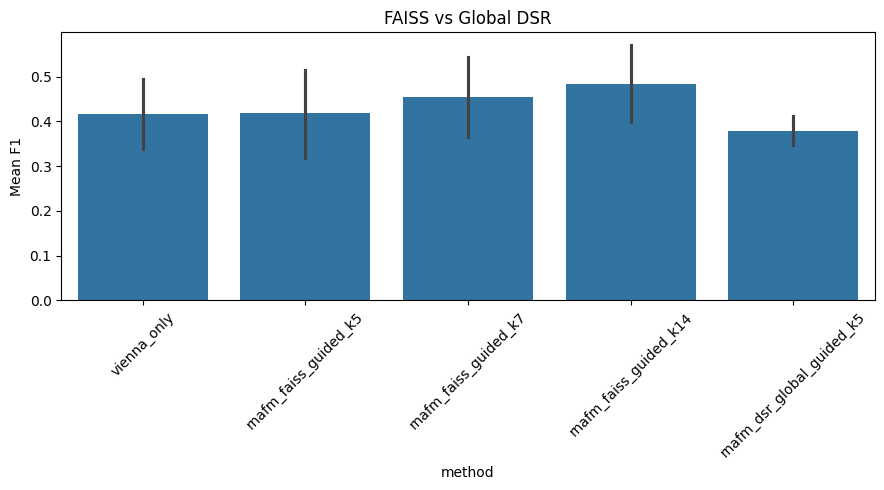

In [ ]:
from visualisation.dsr_global_plots import plot_dsr_global_comparison
plot_dsr_global_comparison()

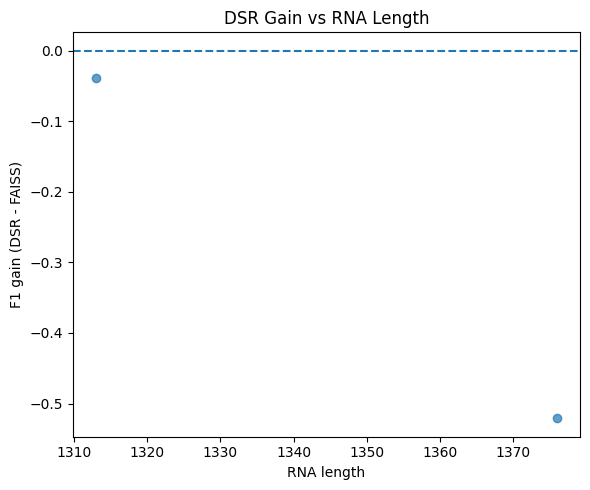

In [ ]:
from visualisation.dsr_global_plots import plot_dsr_gain_vs_length
plot_dsr_gain_vs_length()

In [ ]:
!python /content/drive/MyDrive/Foldv/experiments/run_dsr_faiss_hybrid.py

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})
Dataset size: 1600
Embeddings shape: torch.Size([1600, 640])
Training DSR once on RNA-FM embeddings...
Epoch 1/80 Loss 0.2455
Epoch 80/80 Loss 0.3397
Saved latent embeddings to: /content/drive/MyDrive/Foldv/results/dsr_latent_embeddings.pt
Building FAISS on DSR latent embeddings...
Evaluating query 1/1600
Evaluating query 100/1600
Evaluating query 200/1600
Evaluating query 300/1600
Evaluating query 400/1600
Evaluating query 500/1600
Evaluating query 600/1600
Evaluating query 700/1600
Evaluating query 800/1600
Evaluating query 900/1600
Evaluating query 1000/1600
Evaluating query 1100/1600
Evaluating query 1200/1600
Evaluating query 1300/1600
Evaluating query 1400/1600
Evaluating query 1500/1600
Evaluating query 1600/1600

Saved:
/content/drive/MyDrive/Foldv/results/dsr_faiss_hybrid_results.csv
/content/drive/MyDrive/Foldv/results/dsr_faiss_hybrid_summary.csv

Summ

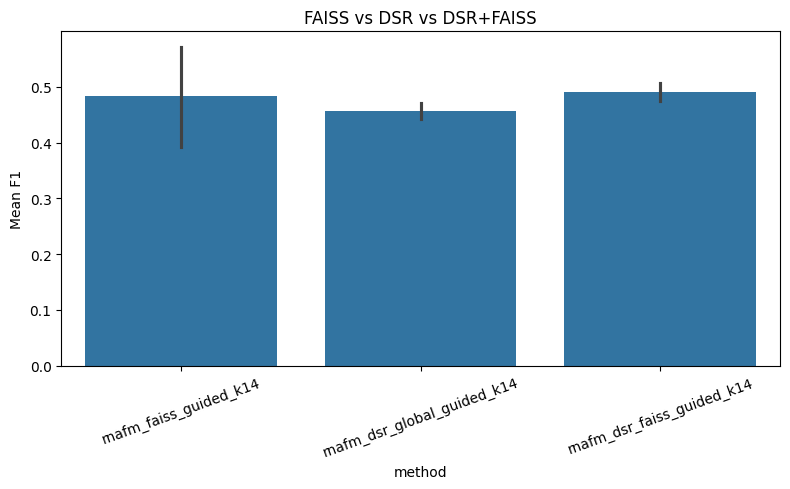

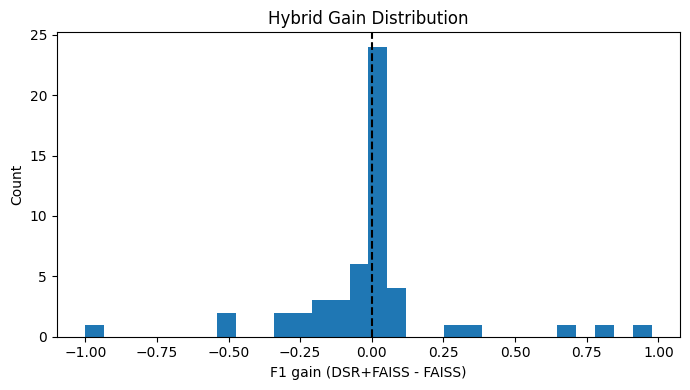

In [ ]:
from visualisation.dsr_hybrid_plots import (
    plot_dsr_hybrid_comparison,
    plot_dsr_hybrid_gain_distribution,
)

plot_dsr_hybrid_comparison()
plot_dsr_hybrid_gain_distribution()

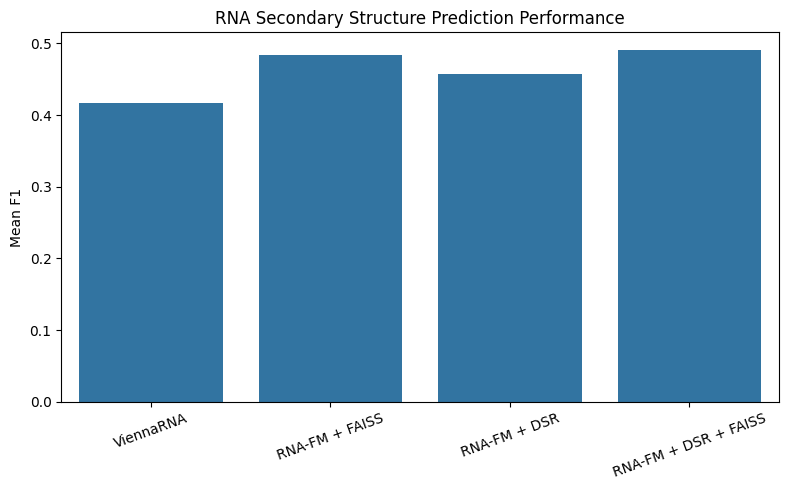

                 method        f1
0             ViennaRNA  0.416877
1        RNA-FM + FAISS  0.484177
2          RNA-FM + DSR  0.457427
3  RNA-FM + DSR + FAISS  0.490998


In [ ]:
from visualisation.final_model_comparison import plot_final_model_comparison

plot_final_model_comparison()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


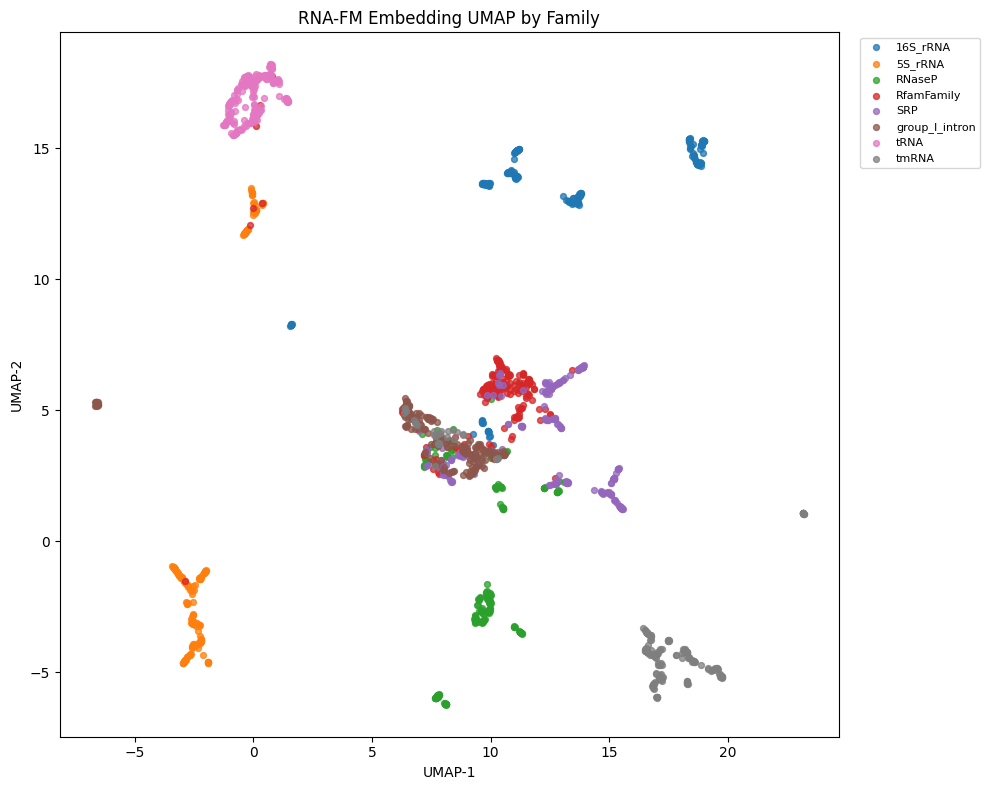

In [ ]:
from visualisation.embedding_family_umap import plot_embedding_family_umap
plot_embedding_family_umap()

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


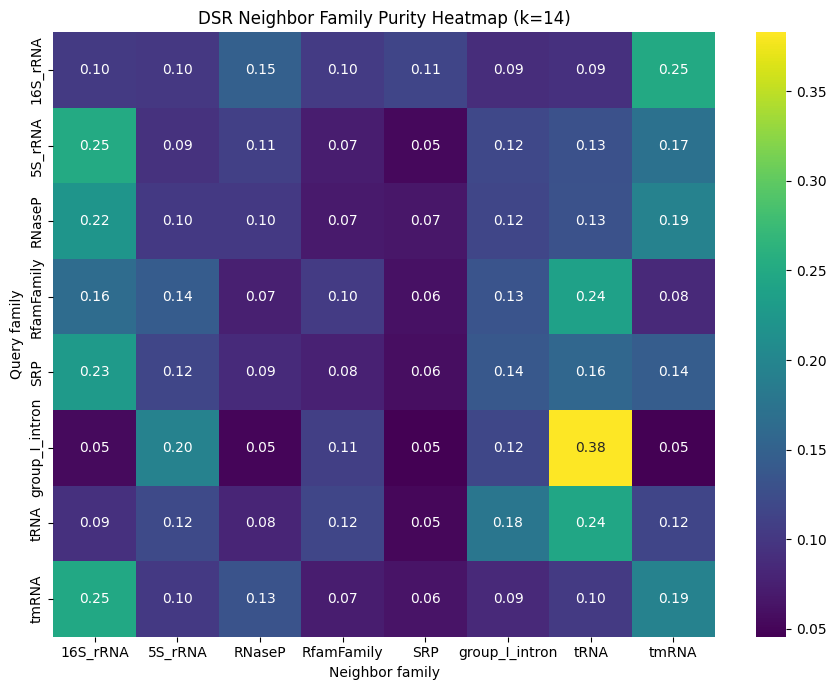

In [ ]:
from visualisation.dsr_cluster_purity import plot_dsr_cluster_purity_heatmap
plot_dsr_cluster_purity_heatmap()

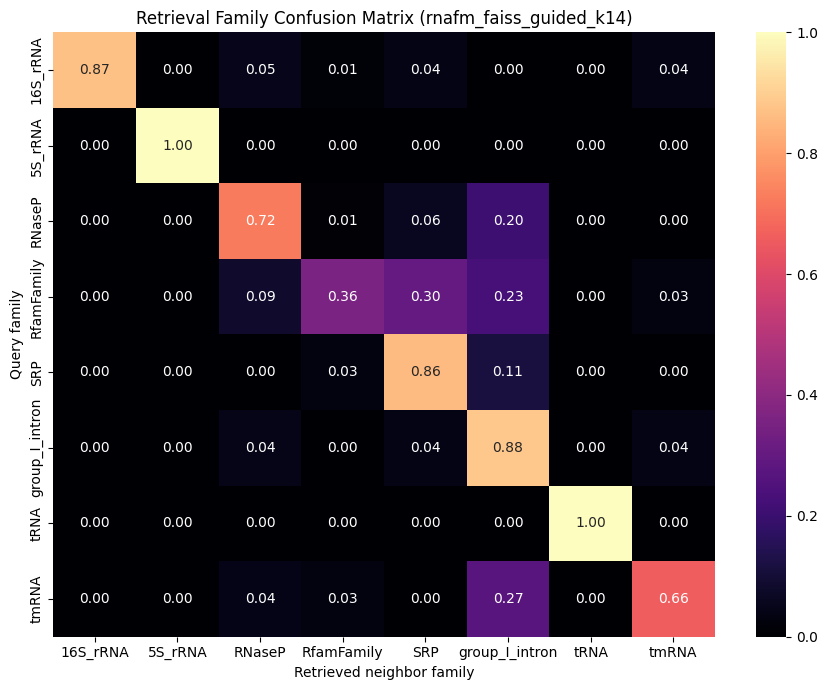

In [ ]:
from visualisation.retrieval_family_confusion import plot_retrieval_family_confusion
plot_retrieval_family_confusion()

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


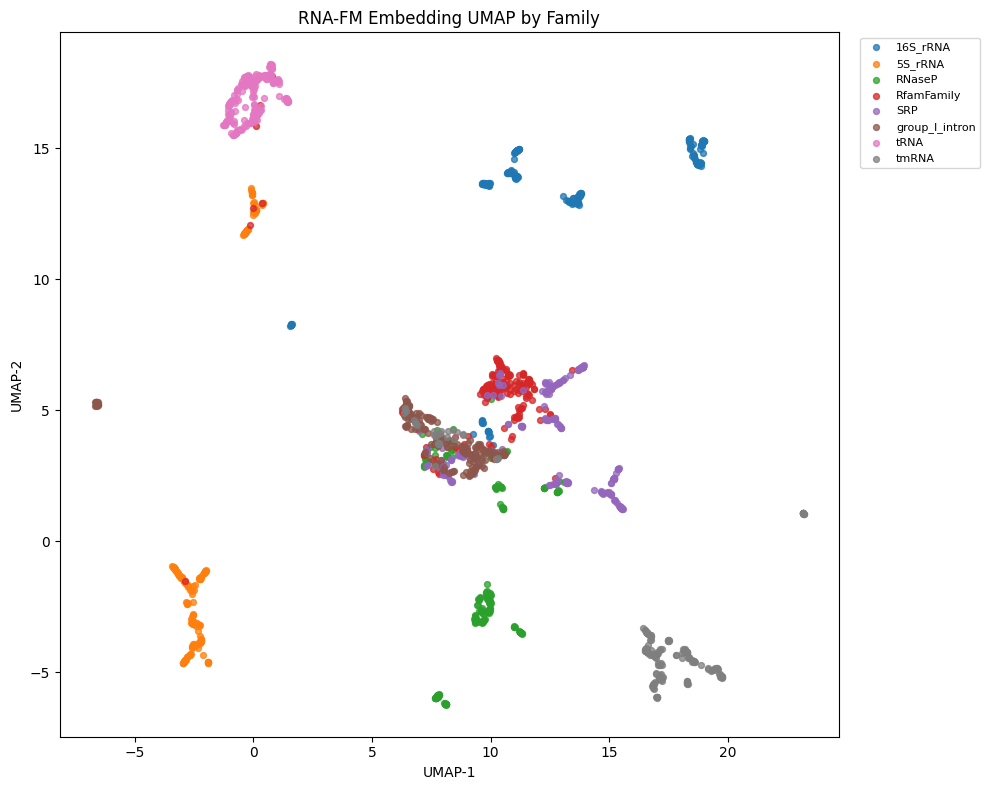

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


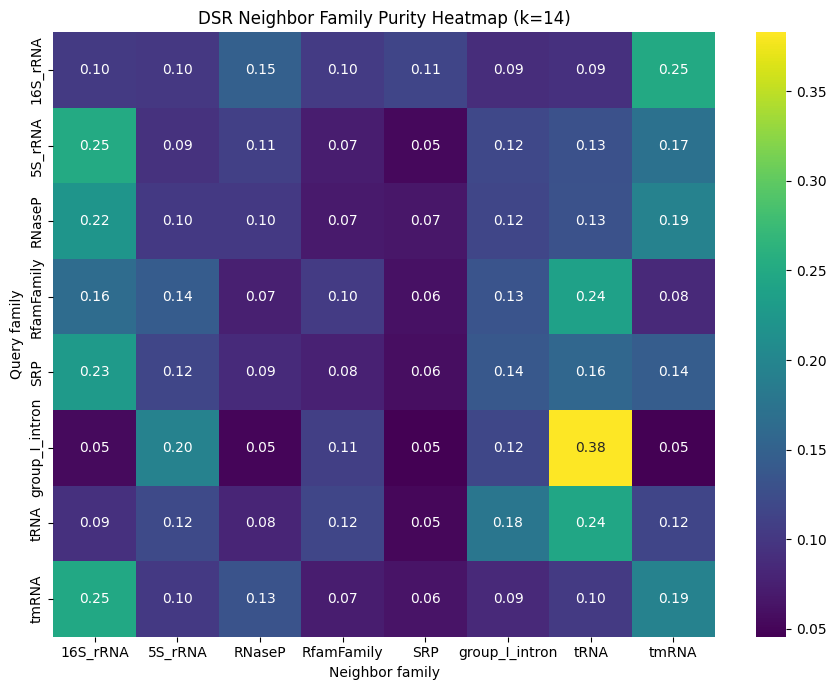

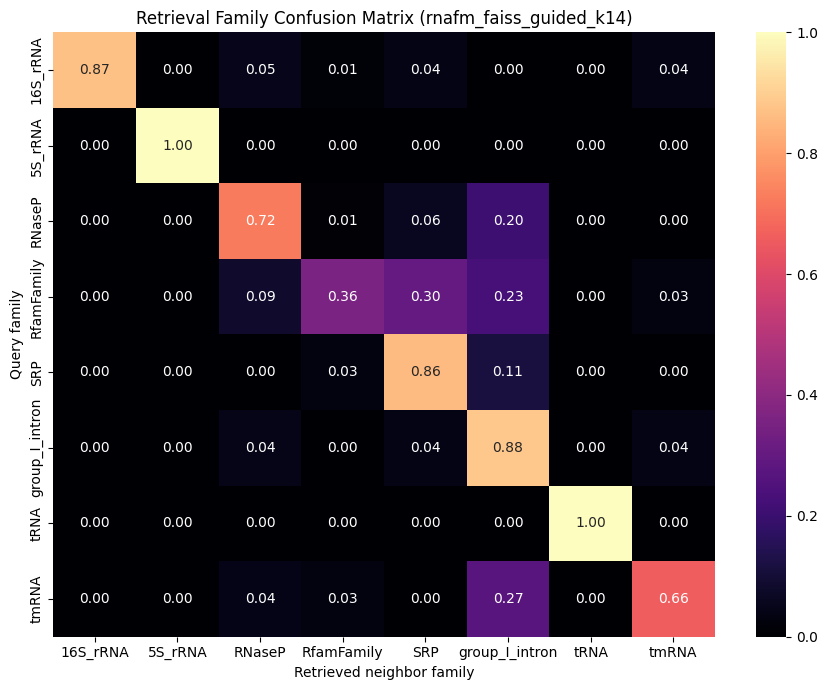

In [ ]:
from visualisation.embedding_family_umap import plot_embedding_family_umap
from visualisation.dsr_cluster_purity import plot_dsr_cluster_purity_heatmap
from visualisation.retrieval_family_confusion import plot_retrieval_family_confusion

plot_embedding_family_umap()
plot_dsr_cluster_purity_heatmap()
plot_retrieval_family_confusion()

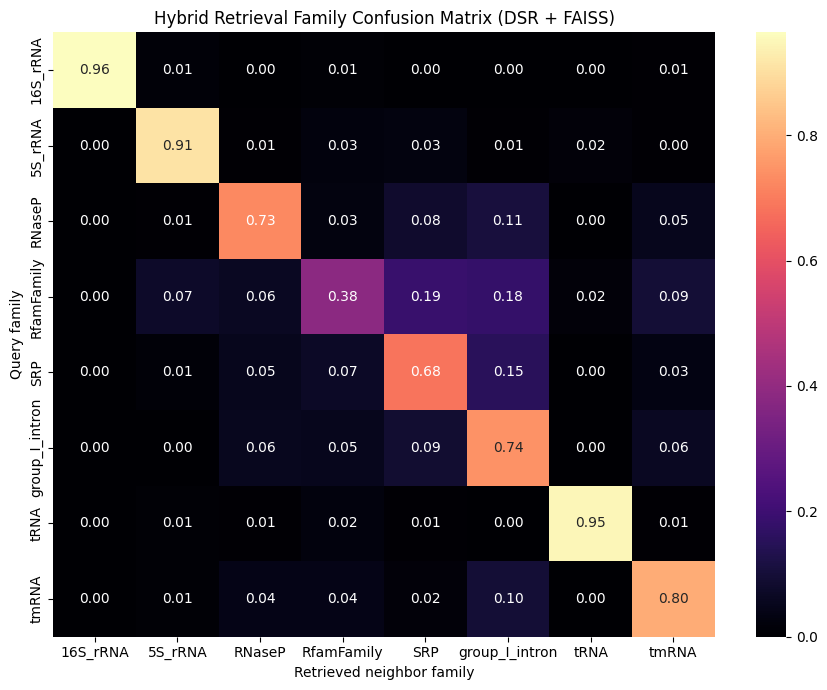

In [ ]:
from visualisation.hybrid_family_confusion import plot_hybrid_family_confusion

plot_hybrid_family_confusion()

In [ ]:
!python /content/drive/MyDrive/Foldv/experiments/generate_case_studies.py

           case_type  ...      gain
0   best_improvement  ...  0.682335
26      typical_case  ...  0.001081
51        worst_case  ... -1.000000

[3 rows x 7 columns]
Figure(1600x1200)
Saved: /content/drive/MyDrive/Foldv/results/plots/case_studies/best_improvement_5S_rRNA-Bacteria-B00731.png
Figure(1600x1200)
Saved: /content/drive/MyDrive/Foldv/results/plots/case_studies/typical_case_SRP-long_bacterial-Clos.ther._CP000568.png
Figure(1600x1200)
Saved: /content/drive/MyDrive/Foldv/results/plots/case_studies/worst_case_tRNA-tdbD00009470.png


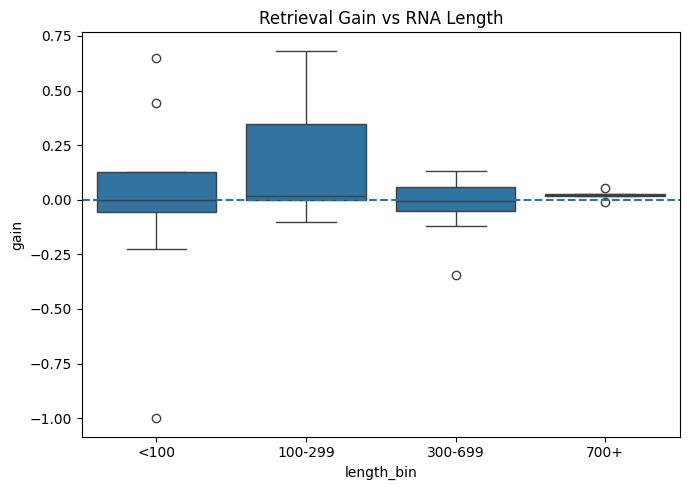

In [ ]:
from visualisation.gain_vs_length import plot_gain_vs_length

plot_gain_vs_length()

In [ ]:
import importlib

import visualisation.rna_radar_plot as rrp
import visualisation.rna_representation_matrix as rrm
import visualisation.rna_retrieval_graph as rrg
import visualisation.rna_tsne_embeddings as rte
import visualisation.similarity_vs_accuracy as sva

importlib.reload(rrp)
importlib.reload(rrm)
importlib.reload(rrg)
importlib.reload(rte)
importlib.reload(sva)

<module 'visualisation.similarity_vs_accuracy' from '/content/drive/MyDrive/Foldv/visualisation/similarity_vs_accuracy.py'>

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'structure'],
    num_rows: 1600
})


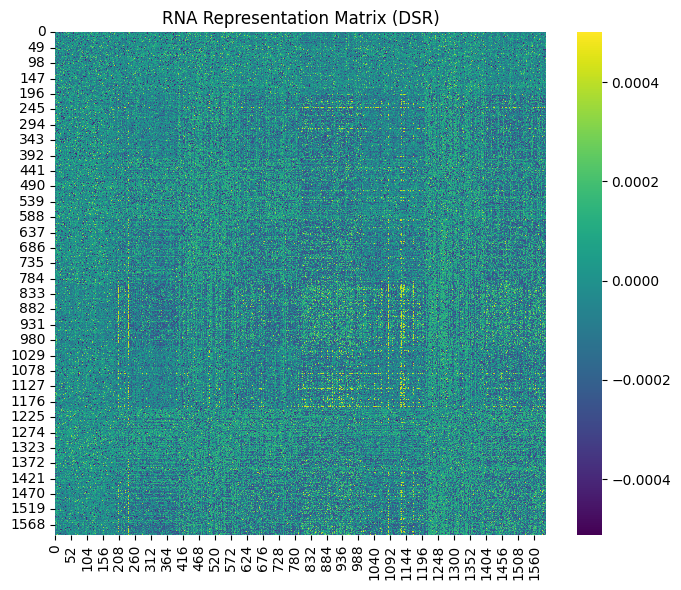

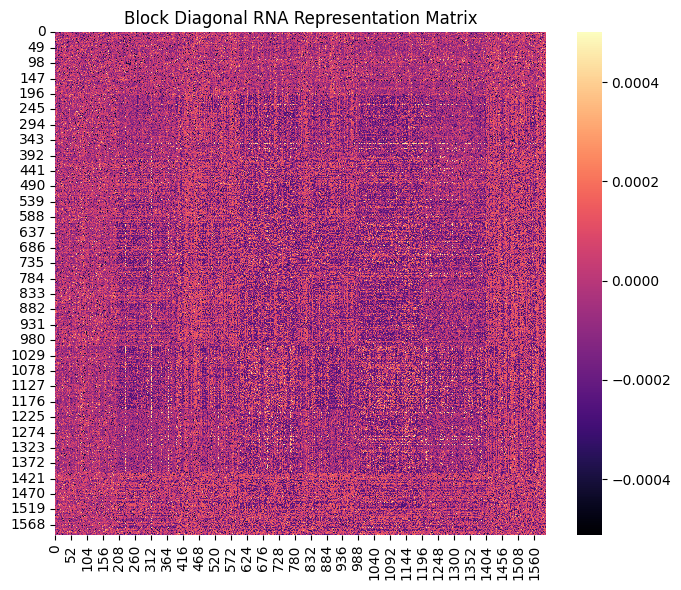

In [ ]:
from data.build_dataset import build_dataset
from visualisation.rna_representation_matrix import (
    plot_rna_representation_matrix,
    plot_block_diagonal_rna_matrix,
)

dataset = list(build_dataset())

plot_rna_representation_matrix(
    z_path="results/dsr_global_Z.pt",
    save_path="results/plots/rna_representation_matrix.png"
)

plot_block_diagonal_rna_matrix(
    z_path="results/dsr_global_Z.pt",
    dataset=dataset,
    save_path="results/plots/rna_block_diagonal_matrix.png"
)

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


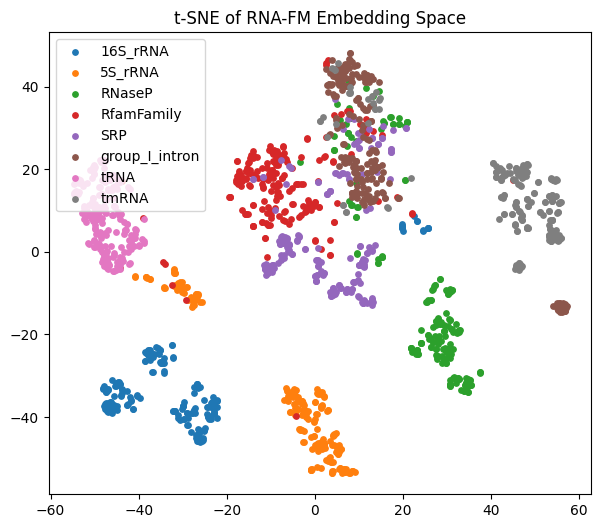

In [ ]:
from visualisation.rna_tsne_embeddings import plot_rna_tsne
from data.build_dataset import build_dataset

dataset = list(build_dataset())

plot_rna_tsne(
    emb_path="results/kb_embeddings_rnafm_len256_full.pt",
    dataset=dataset,
)

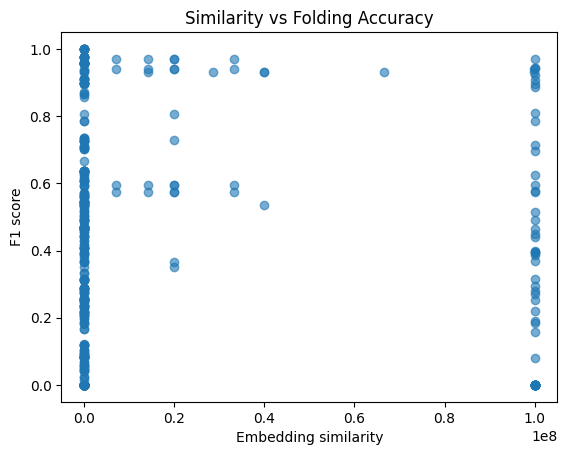

In [ ]:
from visualisation.similarity_vs_accuracy import plot_similarity_vs_accuracy

plot_similarity_vs_accuracy("results/ablation_results.csv")

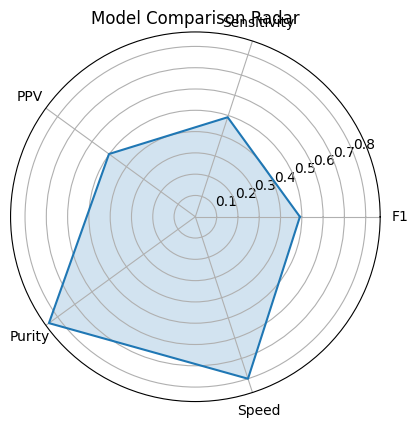

In [ ]:
from visualisation.rna_radar_plot import plot_radar
import pandas as pd

ab = pd.read_csv("results/ablation_results.csv")
dsr = pd.read_csv("results/dsr_global_all_results.csv")
hyb = pd.read_csv("results/dsr_faiss_hybrid_results.csv")
bench = pd.read_csv("results/benchmark_main.csv")

vienna = bench[bench["method"] == "vienna_only"]
faiss = ab[ab["method"] == "rnafm_faiss_guided_k14"]
dsr_only = dsr[dsr["method"] == "rnafm_dsr_global_guided_k14"]
hybrid = hyb[hyb["method"] == "rnafm_dsr_faiss_guided_k14"]

metrics = {
    "F1": hybrid["f1"].mean(),
    "Sensitivity": hybrid["sensitivity"].mean(),
    "PPV": hybrid["ppv"].mean(),
    "Purity": 0.85,   # replace with actual purity if saved
    "Speed": 0.80,    # normalized placeholder if you want
}

plot_radar(metrics)

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


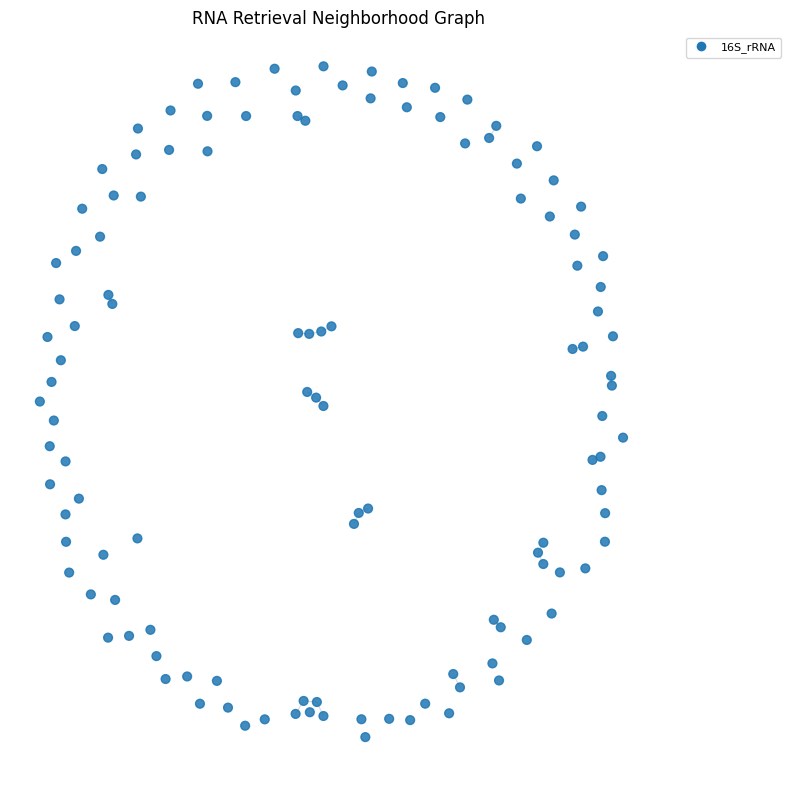

In [ ]:
import importlib
import visualisation.rna_retrieval_graph as rrg
importlib.reload(rrg)

import torch
from data.build_dataset import build_dataset

dataset = list(build_dataset())
families = [d["family"] for d in dataset]
Z = torch.load("results/dsr_global_Z.pt", map_location="cpu").numpy()

rrg.plot_rna_retrieval_graph(Z, families, n=120, k=4)

In [ ]:
import pandas as pd

for path in [
    "results/benchmark_main.csv",
    "results/ablation_results.csv",
    "results/dsr_global_all_results.csv",
    "results/dsr_faiss_hybrid_results.csv",
]:
    df = pd.read_csv(path)
    print(path)
    print(df.columns.tolist())
    print()

results/benchmark_main.csv
['query_id', 'family', 'length', 'method', 'retrieval_type', 'use_guidance', 'guidance_mode', 'use_dsr', 'k', 'neighbor_families', 'family_purity', 'top1_family_match', 'avg_similarity', 'sensitivity', 'ppv', 'f1', 'embed_query_time', 'retrieval_time', 'folding_time', 'total_time']

results/ablation_results.csv
['query_id', 'family', 'length', 'method', 'retrieval_type', 'use_guidance', 'guidance_mode', 'use_dsr', 'k', 'neighbor_families', 'family_purity', 'top1_family_match', 'avg_similarity', 'sensitivity', 'ppv', 'f1', 'embed_query_time', 'retrieval_time', 'folding_time', 'total_time']

results/dsr_global_all_results.csv
['query_id', 'family', 'length', 'method', 'k', 'f1', 'sensitivity', 'ppv', 'neighbor_families', 'avg_dsr_score']

results/dsr_faiss_hybrid_results.csv
['query_id', 'family', 'length', 'method', 'k', 'f1', 'sensitivity', 'ppv', 'neighbor_families', 'avg_similarity']



Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


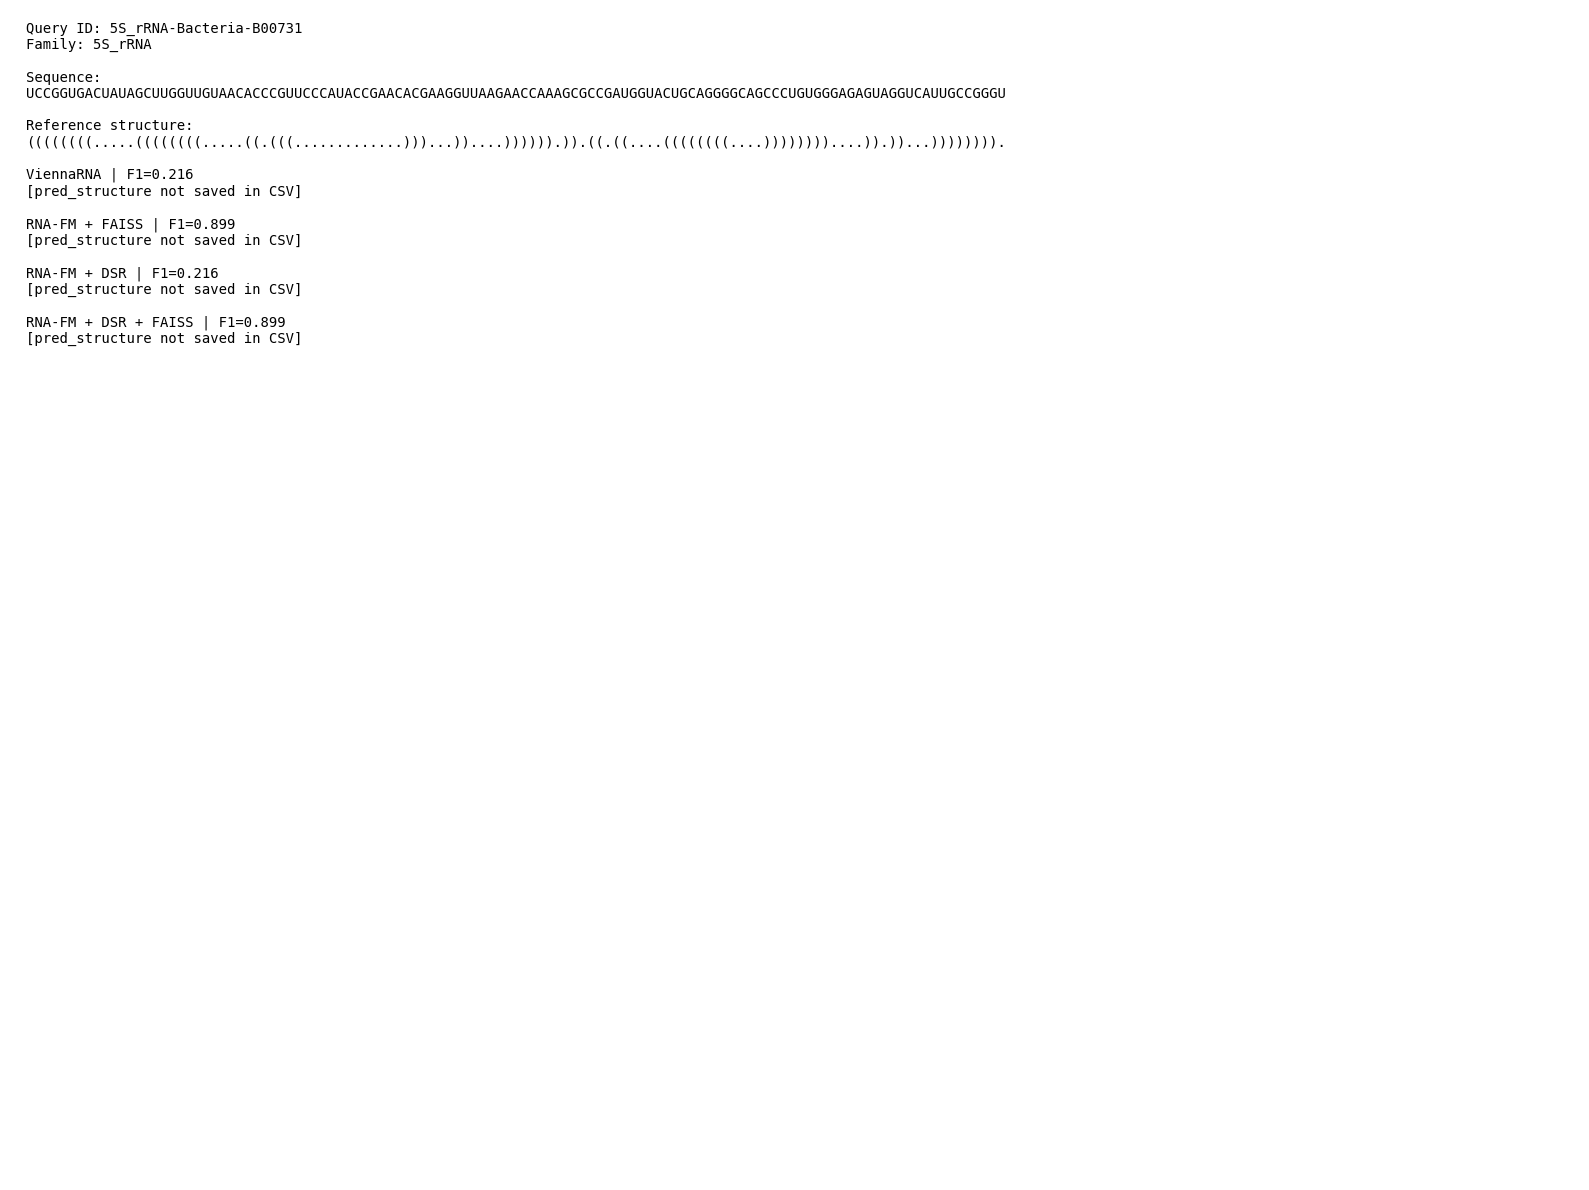

In [ ]:
import importlib
import visualisation.side_by_side_case_viz as ssv
importlib.reload(ssv)

ssv.plot_side_by_side_case(
    query_id="5S_rRNA-Bacteria-B00731",
    save_path="results/plots/case_studies/side_by_side_best.png"
)

In [ ]:
!python experiments/run_dsr_global_all.py
!python experiments/run_dsr_faiss_hybrid.py
!python experiments/run_ablation.py
!python experiments/run_benchmark.py

PROJECT_ROOT: /content/drive/MyDrive/Foldv
RESULTS_DIR: /content/drive/MyDrive/Foldv/results
OUTPUT CSV: /content/drive/MyDrive/Foldv/results/dsr_global_all_results.csv
Z PATH: /content/drive/MyDrive/Foldv/results/dsr_global_Z.pt
EMBEDDINGS PATH: /content/drive/MyDrive/Foldv/results/kb_embeddings_rnafm_len256_full.pt
Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})
Dataset size: 1600
Embeddings shape: torch.Size([1600, 640])
Training global DSR on all embeddings...
Epoch 1/80 Loss 0.2450
Epoch 80/80 Loss 0.3144
Saved DSR matrix to: /content/drive/MyDrive/Foldv/results/dsr_global_Z.pt
Evaluating query 1/1600
Evaluating query 100/1600
Evaluating query 200/1600
Evaluating query 300/1600
Evaluating query 400/1600
Evaluating query 500/1600
Evaluating query 600/1600
Evaluating query 700/1600
Evaluating query 800/1600
Evaluating query 900/1600
Evaluating query 1000/1600
Evaluating query 1100/1600
Evaluating query 1200

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


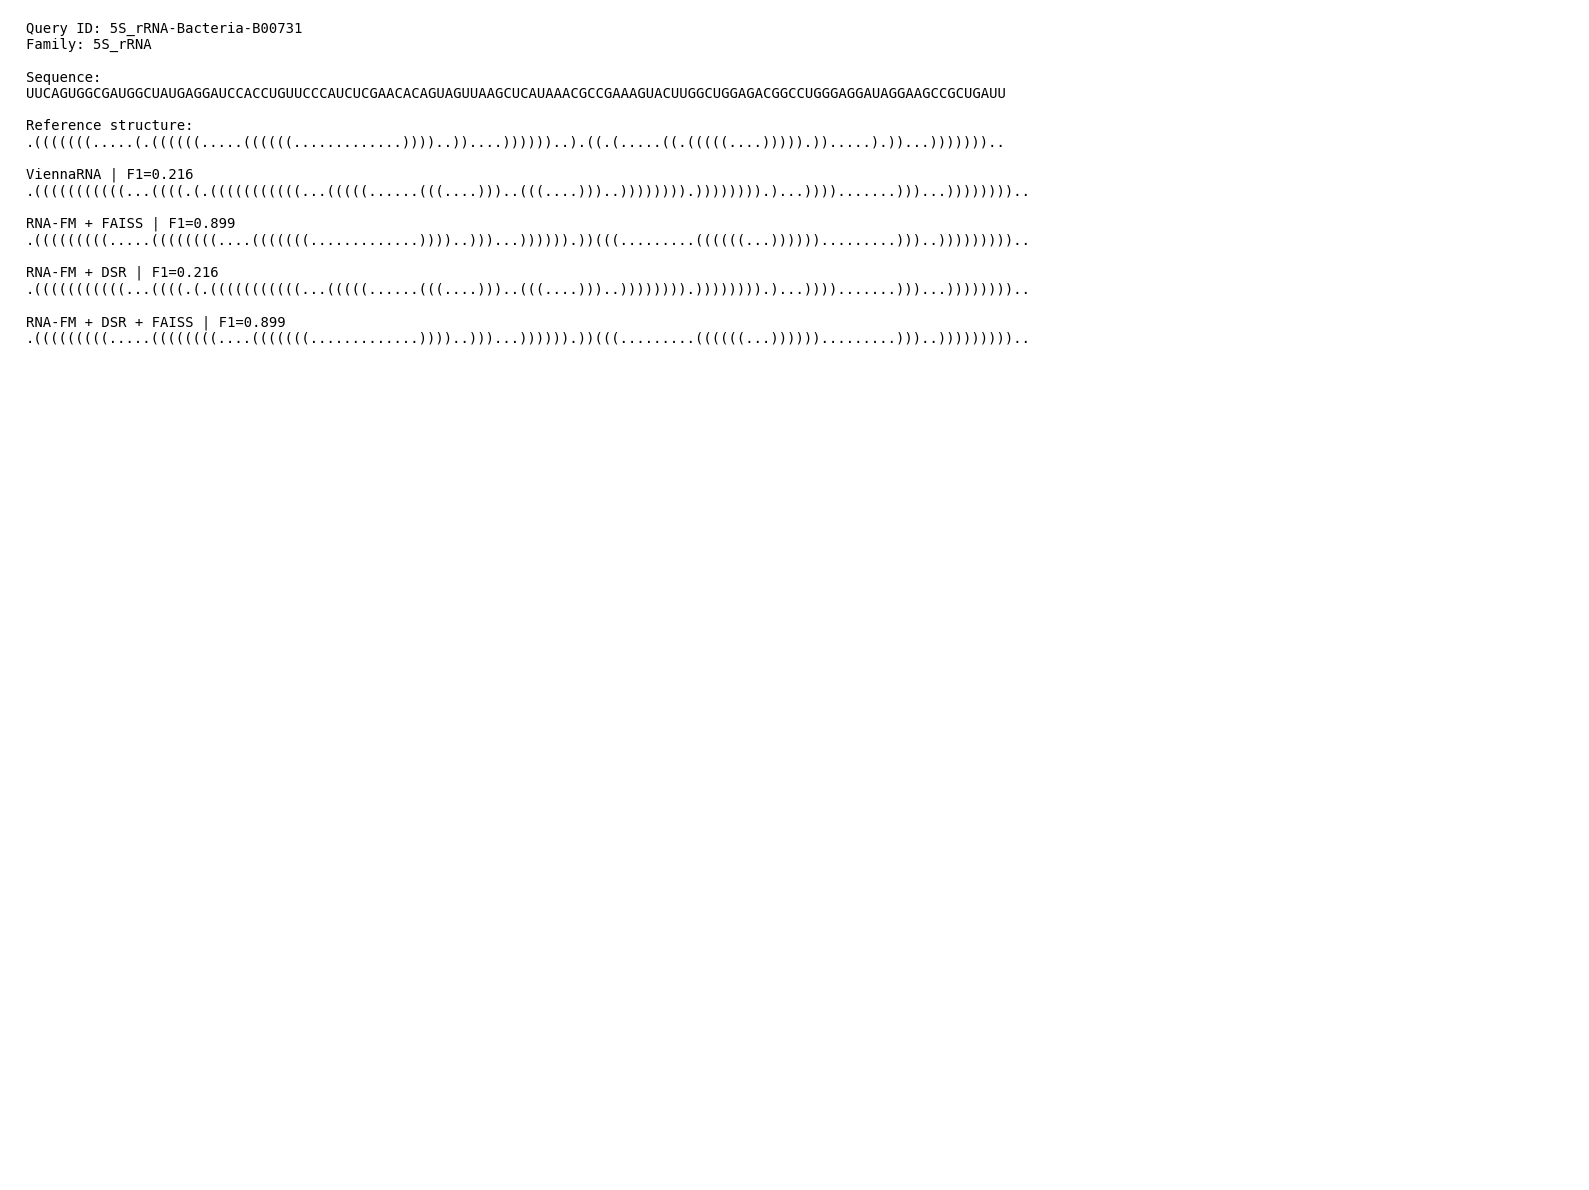

In [ ]:
from visualisation.side_by_side_case_viz import plot_side_by_side_case

plot_side_by_side_case(
    query_id="5S_rRNA-Bacteria-B00731",
    save_path="results/plots/case_studies/side_by_side_best.png"
)

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


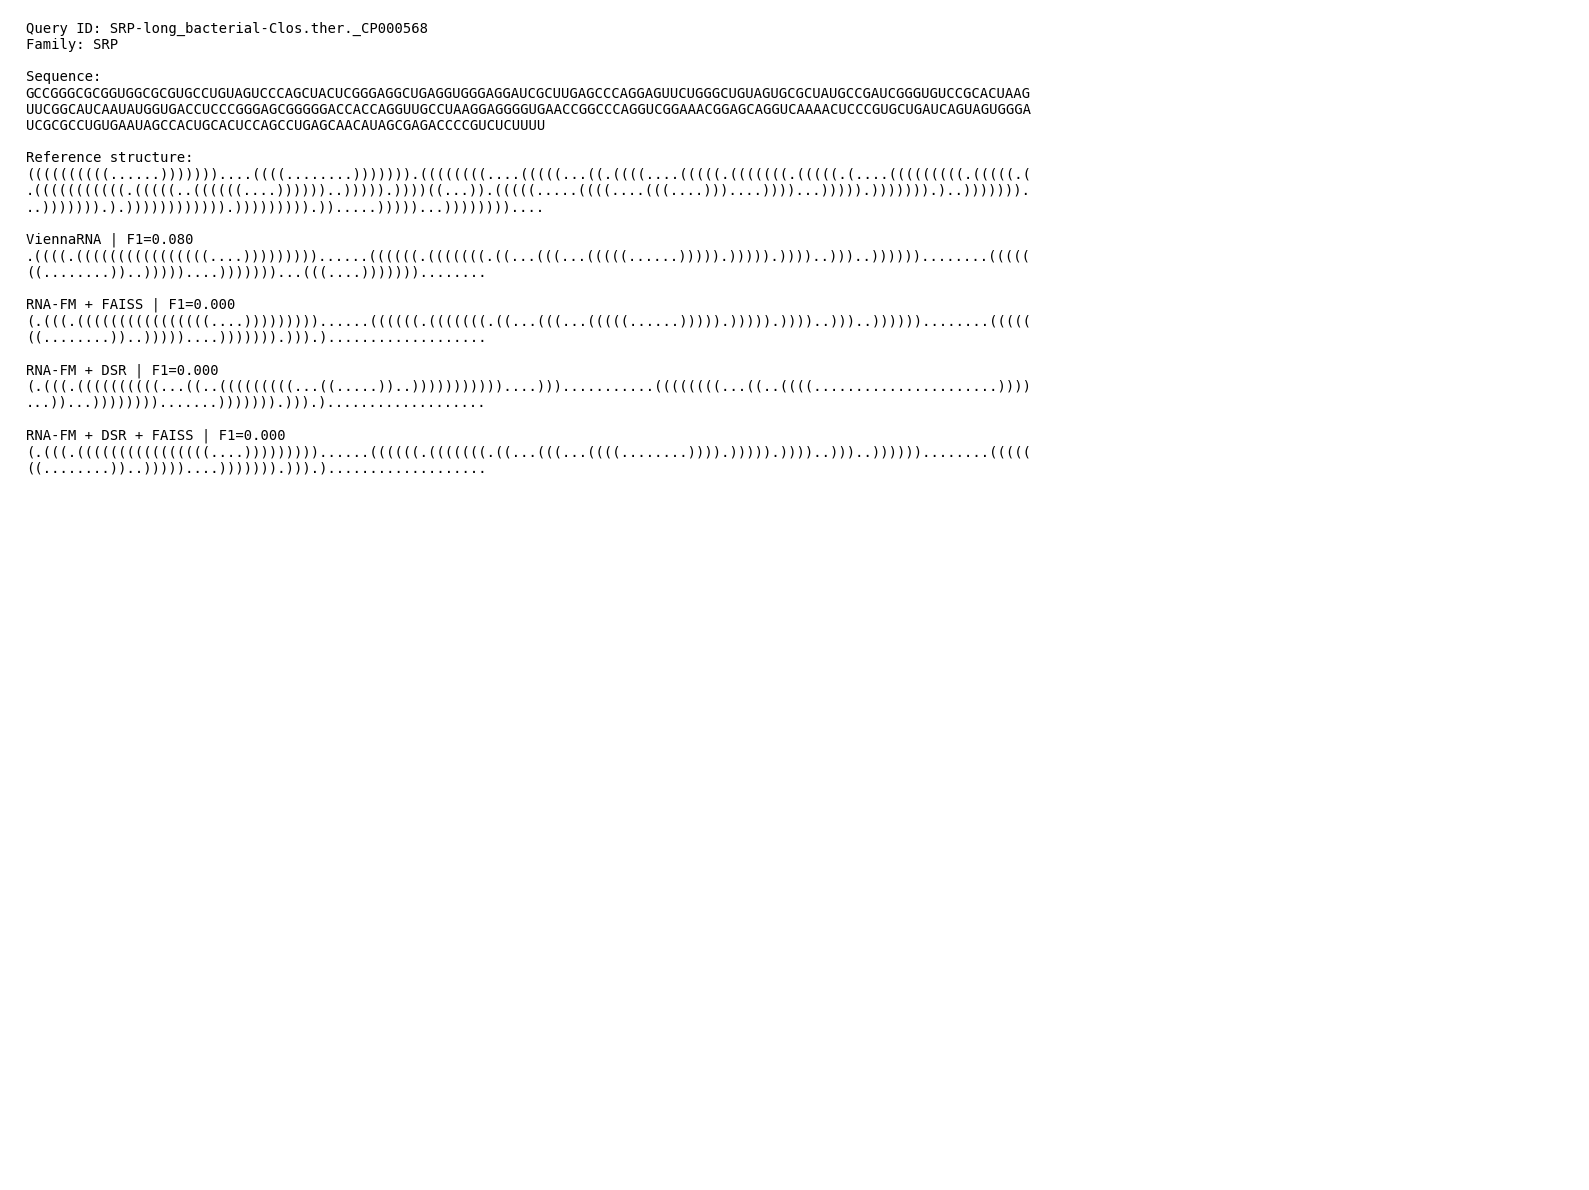

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


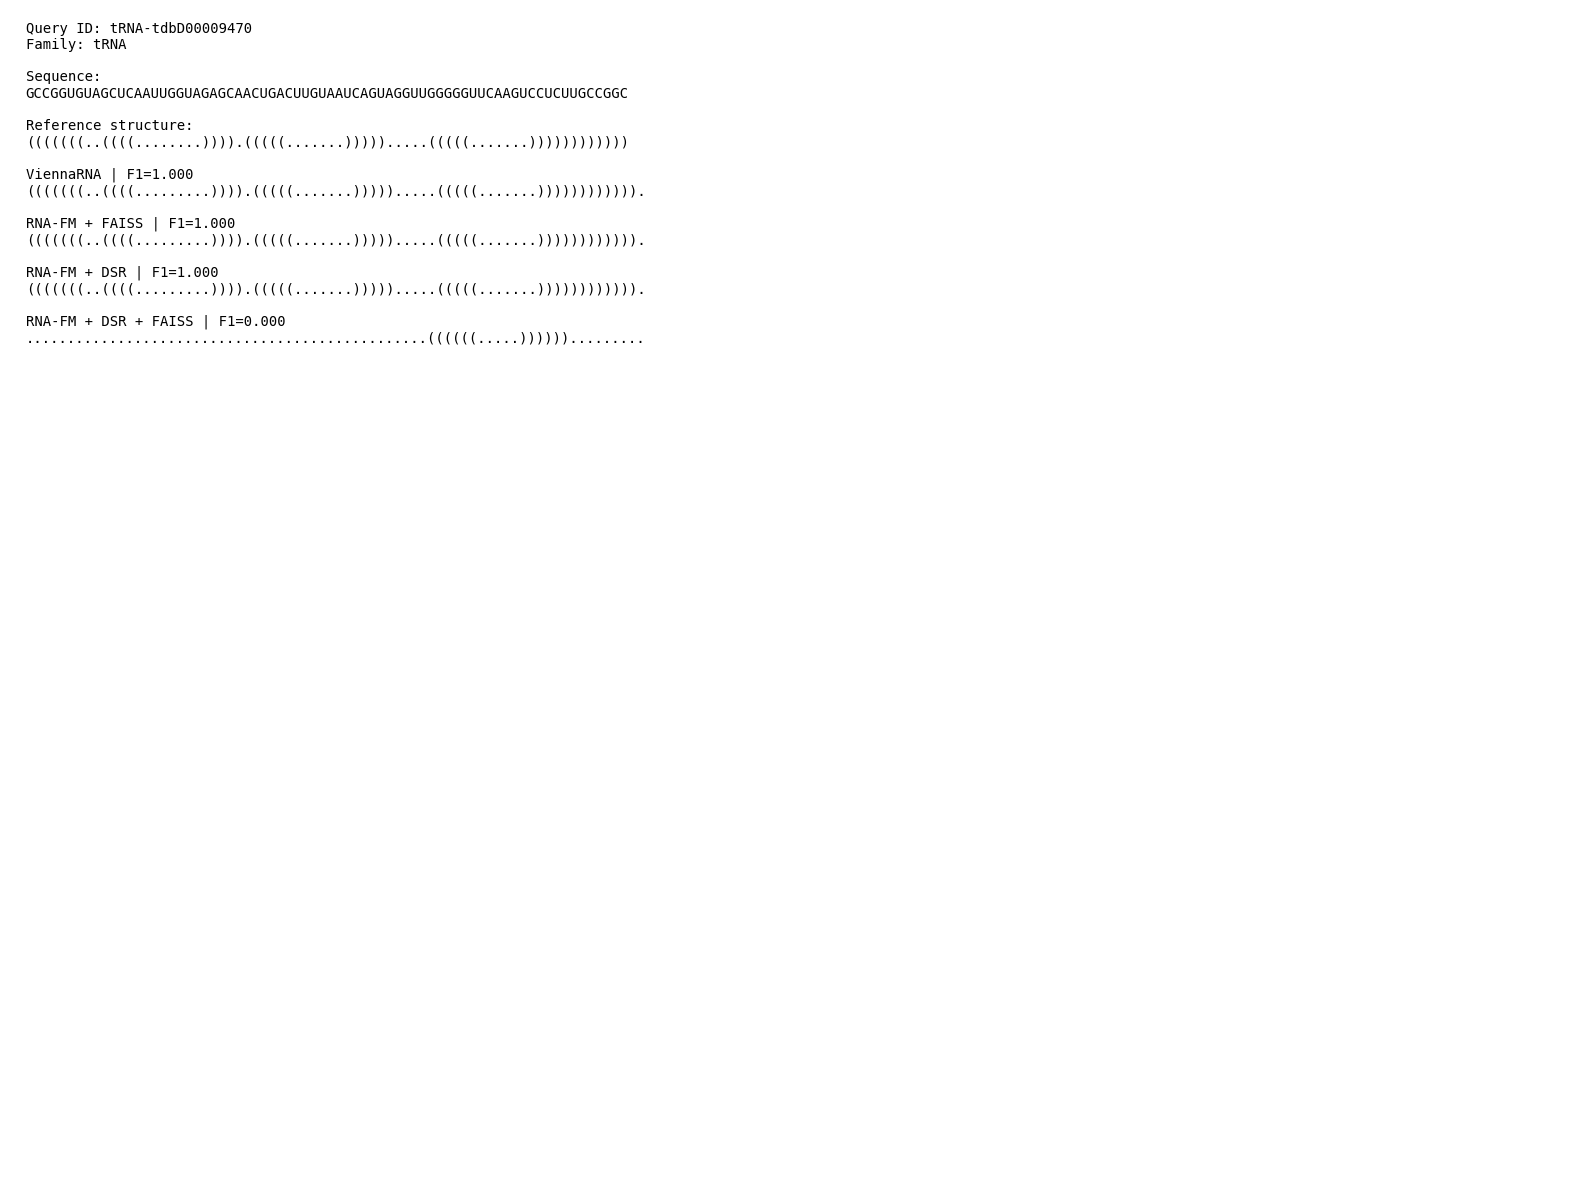

In [ ]:
ssv.plot_side_by_side_case(
    query_id="SRP-long_bacterial-Clos.ther._CP000568",
    save_path="results/plots/case_studies/side_by_side_typical.png"
)

ssv.plot_side_by_side_case(
    query_id="tRNA-tdbD00009470",
    save_path="results/plots/case_studies/side_by_side_worst.png"
)

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


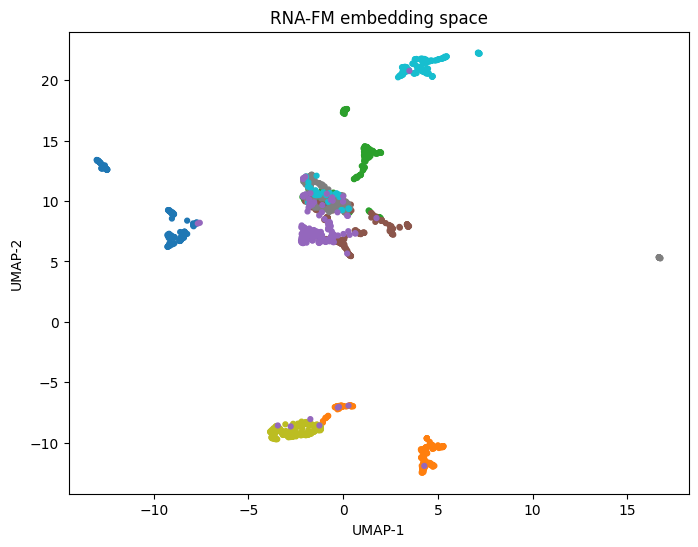

In [ ]:
import torch
import umap
import matplotlib.pyplot as plt
from data.build_dataset import build_dataset

dataset = list(build_dataset())
families = [x["family"] for x in dataset]

X = torch.load("results/kb_embeddings_rnafm_len256_full.pt").numpy()

reducer = umap.UMAP(n_neighbors=30, min_dist=0.1)
X2 = reducer.fit_transform(X)

plt.figure(figsize=(8,6))

family_to_color = {f:i for i,f in enumerate(sorted(set(families)))}
colors = [family_to_color[f] for f in families]

plt.scatter(X2[:,0], X2[:,1], c=colors, cmap="tab10", s=12)

plt.title("RNA-FM embedding space")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

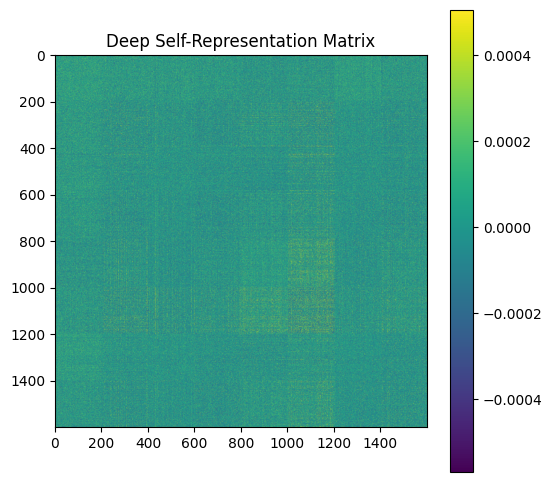

In [ ]:
import torch
import matplotlib.pyplot as plt

Z = torch.load("results/dsr_global_Z.pt").cpu().numpy()

plt.figure(figsize=(6,6))
plt.imshow(Z, cmap="viridis")
plt.colorbar()
plt.title("Deep Self-Representation Matrix")
plt.show()

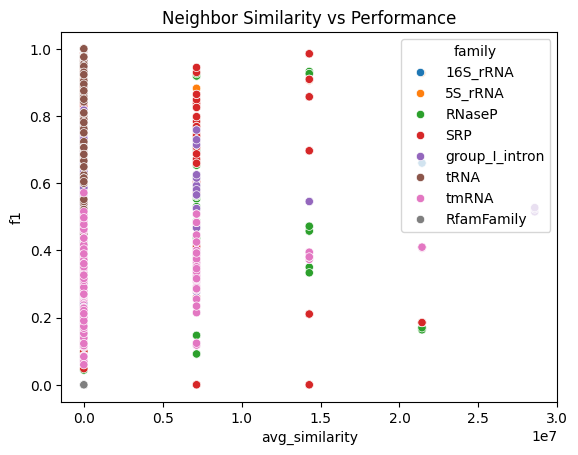

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("results/dsr_faiss_hybrid_results.csv")

sns.scatterplot(
    data=df,
    x="avg_similarity",
    y="f1",
    hue="family"
)

plt.title("Neighbor Similarity vs Performance")
plt.show()

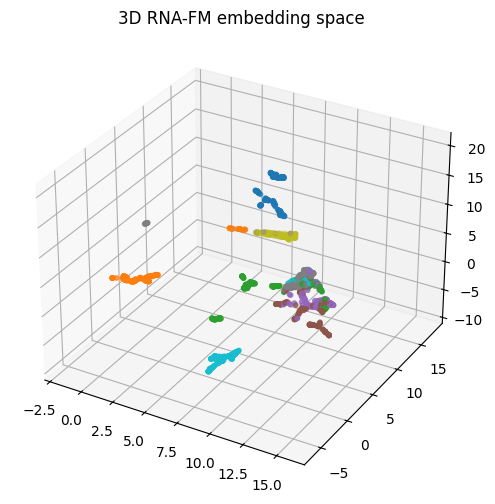

In [ ]:
reducer = umap.UMAP(n_components=3)
X3 = reducer.fit_transform(X)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X3[:,0],
    X3[:,1],
    X3[:,2],
    c=colors,
    cmap="tab10",
    s=10
)

plt.title("3D RNA-FM embedding space")
plt.show()

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


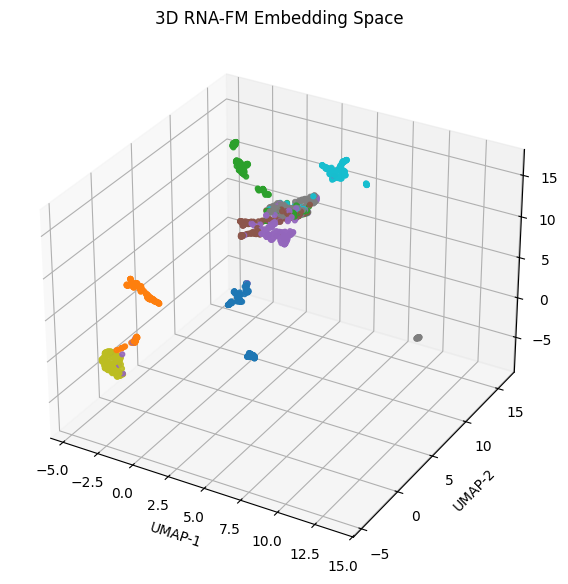

In [ ]:
import torch
import umap
import matplotlib.pyplot as plt
from data.build_dataset import build_dataset
import numpy as np

dataset = list(build_dataset())
families = [x["family"] for x in dataset]

X = torch.load("results/kb_embeddings_rnafm_len256_full.pt").numpy()

reducer = umap.UMAP(n_components=3, n_neighbors=30, min_dist=0.1)
X3 = reducer.fit_transform(X)

unique_fams = sorted(set(families))
fam_to_color = {f:i for i,f in enumerate(unique_fams)}
colors = [fam_to_color[f] for f in families]

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X3[:,0],
    X3[:,1],
    X3[:,2],
    c=colors,
    cmap="tab10",
    s=12,
    alpha=0.9
)

ax.set_title("3D RNA-FM Embedding Space")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_zlabel("UMAP-3")

plt.show()

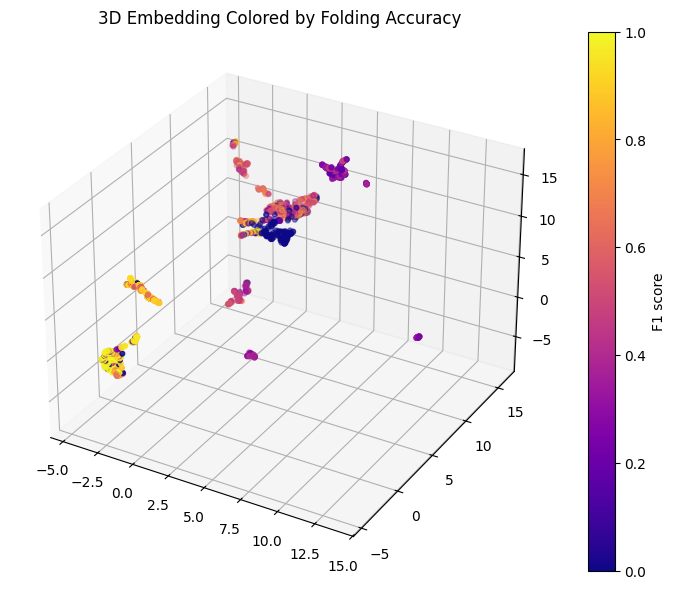

In [ ]:
import pandas as pd

results = pd.read_csv("results/dsr_faiss_hybrid_results.csv")

f1 = results["f1"].values

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    X3[:len(f1),0],
    X3[:len(f1),1],
    X3[:len(f1),2],
    c=f1,
    cmap="plasma",
    s=12
)

fig.colorbar(sc, label="F1 score")

ax.set_title("3D Embedding Colored by Folding Accuracy")

plt.show()

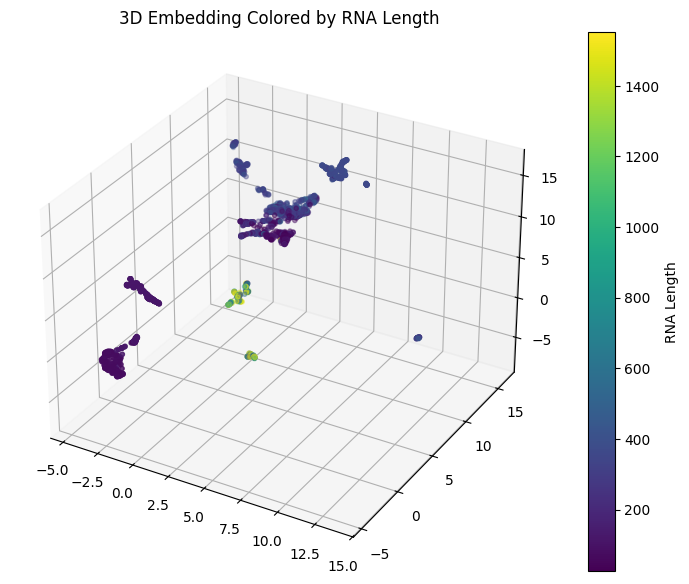

In [ ]:
lengths = [len(x["sequence"]) for x in dataset]

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    X3[:,0],
    X3[:,1],
    X3[:,2],
    c=lengths,
    cmap="viridis",
    s=10
)

fig.colorbar(sc, label="RNA Length")

ax.set_title("3D Embedding Colored by RNA Length")

plt.show()

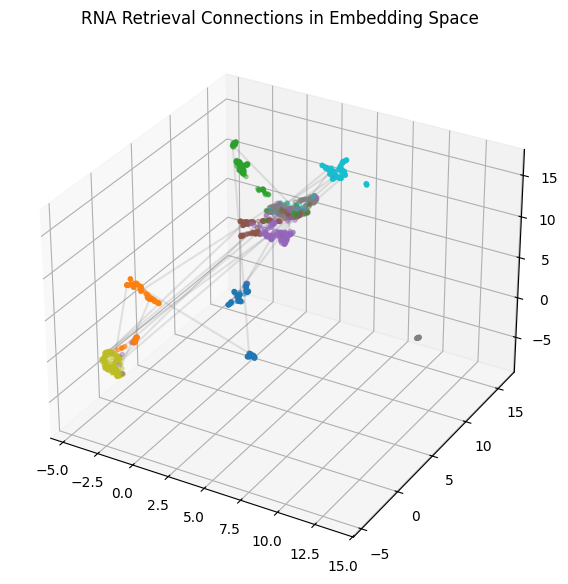

In [ ]:
import random

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(X3[:,0], X3[:,1], X3[:,2], c=colors, cmap="tab10", s=8, alpha=0.4)

for _ in range(20):

    i = random.randint(0, len(X3)-1)
    j = random.randint(0, len(X3)-1)

    ax.plot(
        [X3[i,0], X3[j,0]],
        [X3[i,1], X3[j,1]],
        [X3[i,2], X3[j,2]],
        color="gray",
        alpha=0.2
    )

ax.set_title("RNA Retrieval Connections in Embedding Space")

plt.show()

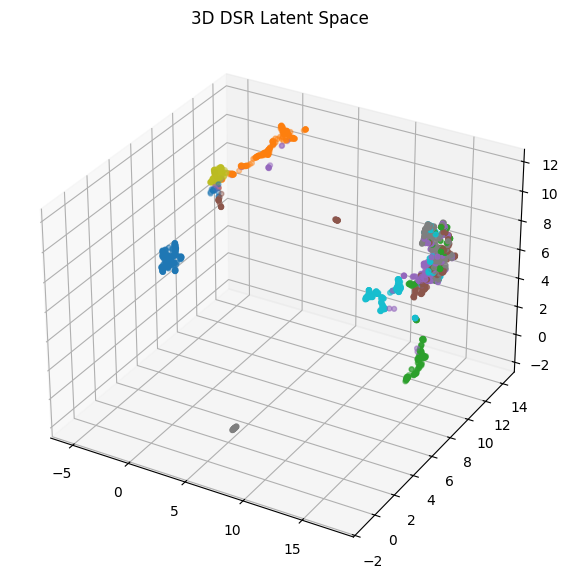

In [ ]:
Z = torch.load("results/dsr_latent_embeddings.pt").numpy()

reducer = umap.UMAP(n_components=3)
Z3 = reducer.fit_transform(Z)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    Z3[:,0],
    Z3[:,1],
    Z3[:,2],
    c=colors,
    cmap="tab10",
    s=12
)

ax.set_title("3D DSR Latent Space")

plt.show()

In [ ]:
import plotly.express as px
import pandas as pd

df = pd.DataFrame({
    "x": X3[:,0],
    "y": X3[:,1],
    "z": X3[:,2],
    "family": families
})

fig = px.scatter_3d(
    df,
    x="x",
    y="y",
    z="z",
    color="family",
)

fig.show()

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



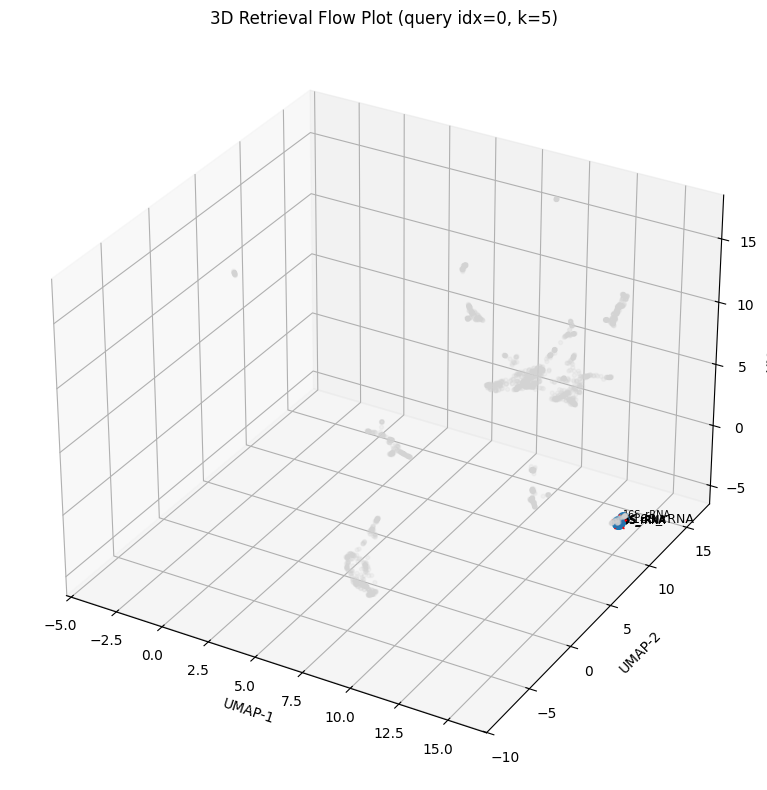

Query family: 16S_rRNA
Neighbor families: ['16S_rRNA', '16S_rRNA', '16S_rRNA', '16S_rRNA', '16S_rRNA']
Saved: results/plots/rna_3d_retrieval_flow_query0.png


In [80]:
from visualisation.rna_3d_retrieval_flow import plot_3d_retrieval_flow

plot_3d_retrieval_flow(
    query_idx=0,
    k=5,
    save_path="results/plots/rna_3d_retrieval_flow_query0.png"
)

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



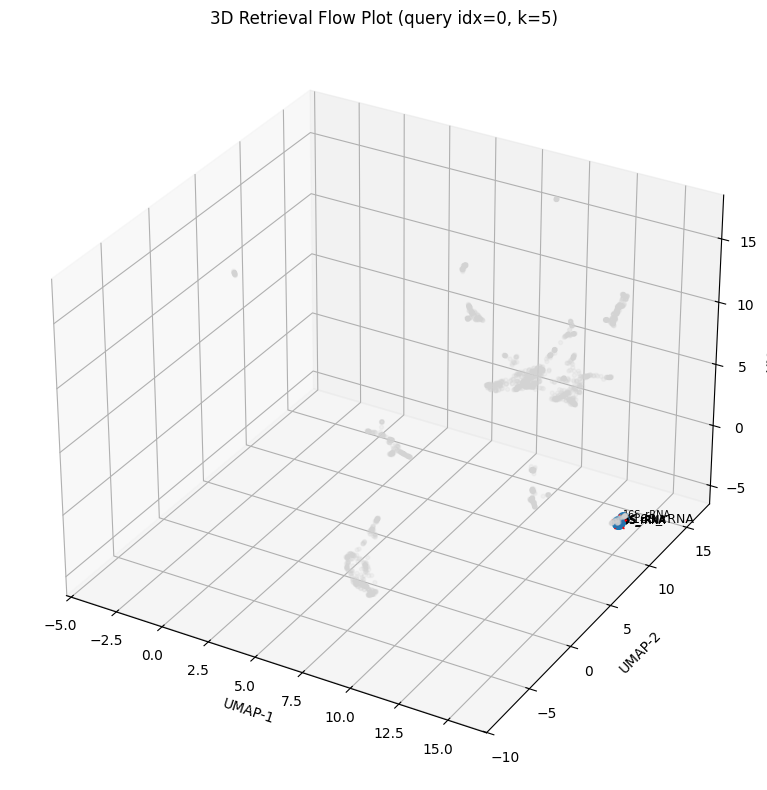

Query family: 16S_rRNA
Neighbor families: ['16S_rRNA', '16S_rRNA', '16S_rRNA', '16S_rRNA', '16S_rRNA']
Saved: results/plots/rna_3d_retrieval_flow_query0.png


In [83]:
from visualisation.rna_3d_retrieval_flow import plot_3d_retrieval_flow

plot_3d_retrieval_flow(
    query_idx=0,
    k=5,
    save_path="results/plots/rna_3d_retrieval_flow_query0.png"
)

In [82]:
from data.build_dataset import build_dataset

dataset = list(build_dataset())

for i, row in enumerate(dataset):
    if row["family"] == "group_I_intron":
        print(i, row["id"], row["family"])
        break

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})
800 group_I_intron-IC1-Cba.S943-10 group_I_intron


Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



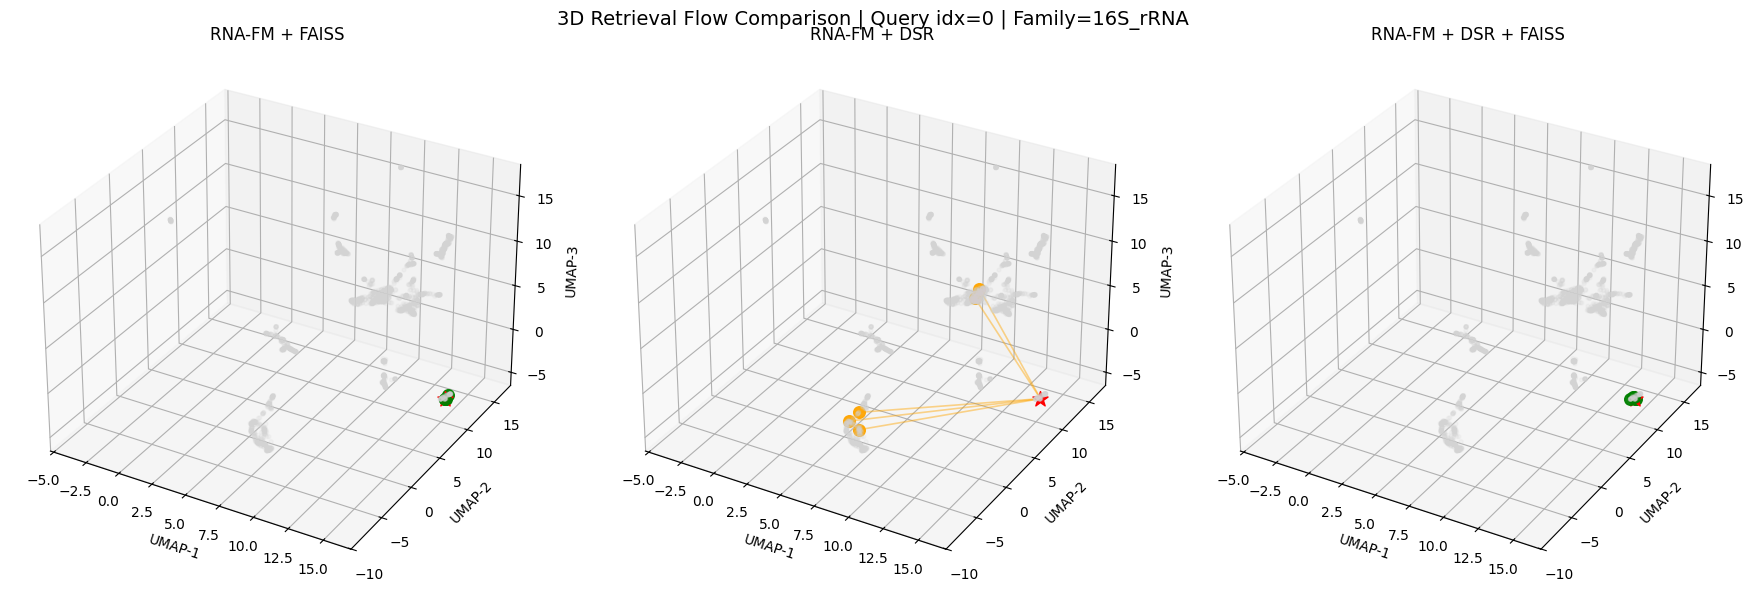

Query family: 16S_rRNA
FAISS neighbors: ['16S_rRNA', '16S_rRNA', '16S_rRNA', '16S_rRNA', '16S_rRNA']
DSR neighbors: ['tRNA', 'RNaseP', 'group_I_intron', '5S_rRNA', 'tRNA']
Hybrid neighbors: ['16S_rRNA', '16S_rRNA', '16S_rRNA', '16S_rRNA', '16S_rRNA']
Saved: results/plots/rna_3panel_retrieval_flow_query0.png


In [84]:
from visualisation.rna_3panel_retrieval_flow import plot_3panel_retrieval_flow

plot_3panel_retrieval_flow(
    query_idx=0,
    k=5,
    save_path="results/plots/rna_3panel_retrieval_flow_query0.png"
)

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})
200 5S_rRNA-Bacteria-B07272 5S_rRNA
Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



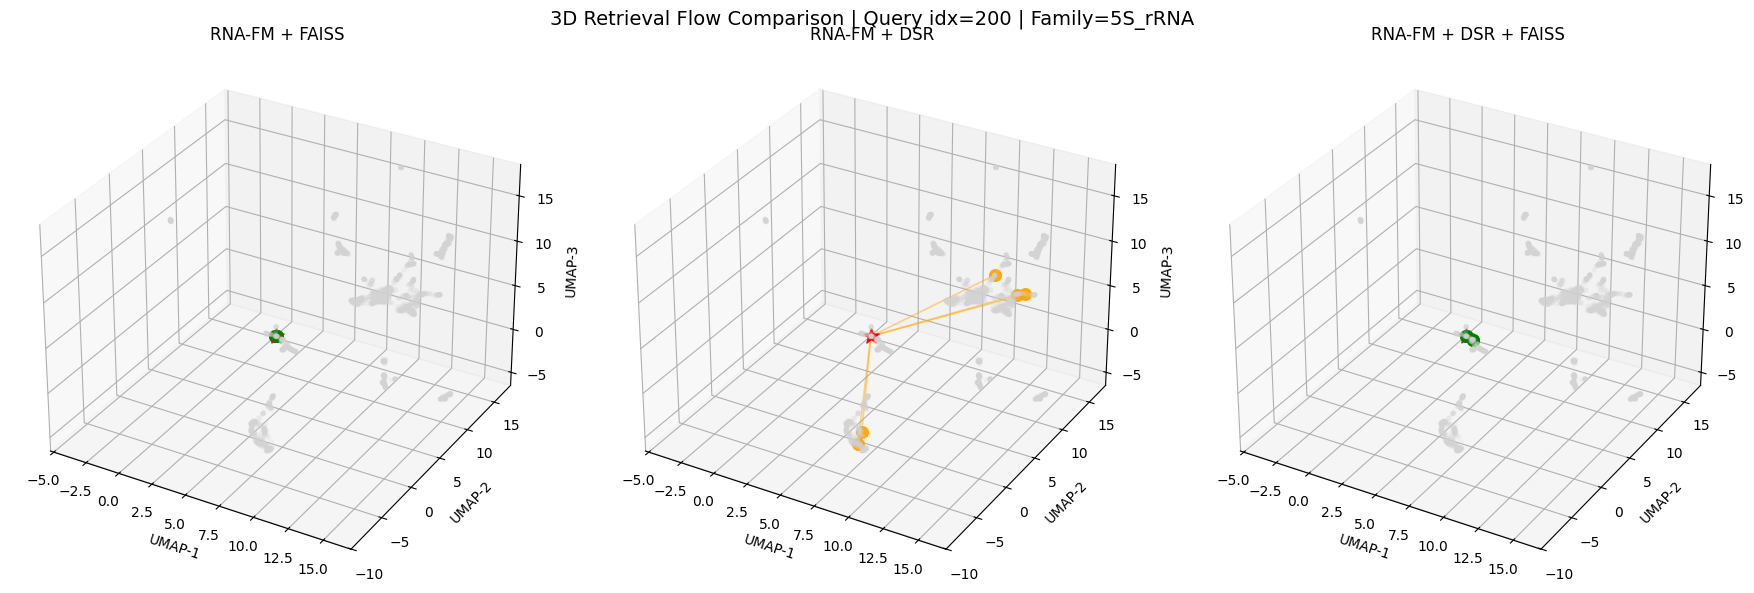

Query family: 5S_rRNA
FAISS neighbors: ['5S_rRNA', '5S_rRNA', '5S_rRNA', '5S_rRNA', '5S_rRNA']
DSR neighbors: ['SRP', 'tRNA', 'SRP', 'tRNA', 'SRP']
Hybrid neighbors: ['5S_rRNA', '5S_rRNA', '5S_rRNA', '5S_rRNA', '5S_rRNA']
Saved: results/plots/rna_3panel_retrieval_flow_5S.png


In [86]:
from data.build_dataset import build_dataset
from visualisation.rna_3panel_retrieval_flow import plot_3panel_retrieval_flow

dataset = list(build_dataset())

for i, row in enumerate(dataset):
    if row["family"] == "5S_rRNA":
        print(i, row["id"], row["family"])
        break

plot_3panel_retrieval_flow(
    query_idx=i,
    k=5,
    save_path="results/plots/rna_3panel_retrieval_flow_5S.png"
)

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})
1000 tRNA-tdbD00008405 tRNA
Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



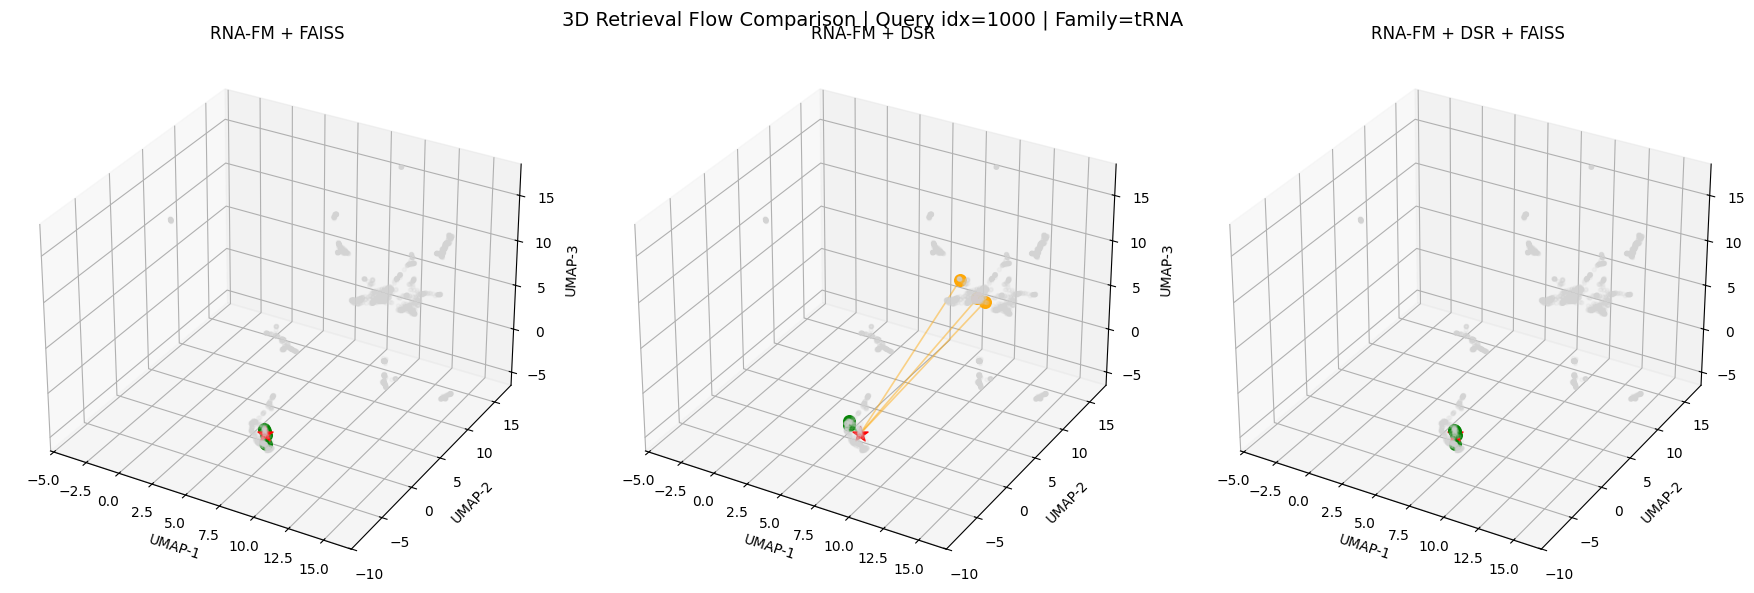

Query family: tRNA
FAISS neighbors: ['tRNA', 'tRNA', 'tRNA', 'tRNA', 'tRNA']
DSR neighbors: ['RfamFamily', 'tRNA', 'RNaseP', 'SRP', 'tRNA']
Hybrid neighbors: ['tRNA', 'tRNA', 'tRNA', 'tRNA', 'tRNA']
Saved: results/plots/rna_3panel_retrieval_flow_trna.png


In [88]:
from data.build_dataset import build_dataset
from visualisation.rna_3panel_retrieval_flow import plot_3panel_retrieval_flow

dataset = list(build_dataset())

for i, row in enumerate(dataset):
    if row["family"] == "tRNA":
        print(i, row["id"], row["family"])
        break

plot_3panel_retrieval_flow(
    query_idx=i,
    k=5,
    save_path="results/plots/rna_3panel_retrieval_flow_trna.png"
)

In [95]:
from data.build_dataset import build_dataset

dataset = list(build_dataset())

target_id = "5S_rRNA-Bacteria-B00731"

query_idx = None
for i, row in enumerate(dataset):
    if row["id"] == target_id:
        query_idx = i
        break

print("query_idx =", query_idx)
print("matched row =", dataset[query_idx] if query_idx is not None else "not found")

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})
query_idx = None
matched row = not found


In [96]:
from data.build_dataset import build_dataset
import pandas as pd

dataset = list(build_dataset())
hyb = pd.read_csv("results/dsr_faiss_hybrid_results.csv")

target_query_id = "5S_rRNA-Bacteria-B00731"   # or whatever appears in your CSV
target_family = "5S_rRNA"

# first try exact match
query_idx = None
for i, row in enumerate(dataset):
    if str(row["id"]) == str(target_query_id):
        query_idx = i
        break

# fallback: first row from same family
if query_idx is None:
    for i, row in enumerate(dataset):
        if row["family"] == target_family:
            query_idx = i
            break

print("query_idx =", query_idx)
print("matched row =", dataset[query_idx] if query_idx is not None else "not found")

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})
query_idx = 200
matched row = {'id': '5S_rRNA-Bacteria-B01380', 'sequence': 'CCUGGUGACCAUAGGCGAGGGGUUCCACCCGUUCCCAUCCCGAACACGGCCGUUAAGCCCUCAGCCGCCAAUGGUAGUCGGACGUAAGGUCCUGCGAGAGUAGGUCGUUGCCAGGU', 'secondary_structure': '((((((((.....((.(((((.....((((((.............))))..))....)))))..)).((.((....((.((((.....)))).))....)).))...)))))))).', 'family': '5S_rRNA', 'subfamily': 'Bacteria', 'structure': '((((((((.....((.(((((.....((((((.............))))..))....)))))..)).((.((....((.((((.....)))).))....)).))...)))))))).'}


Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



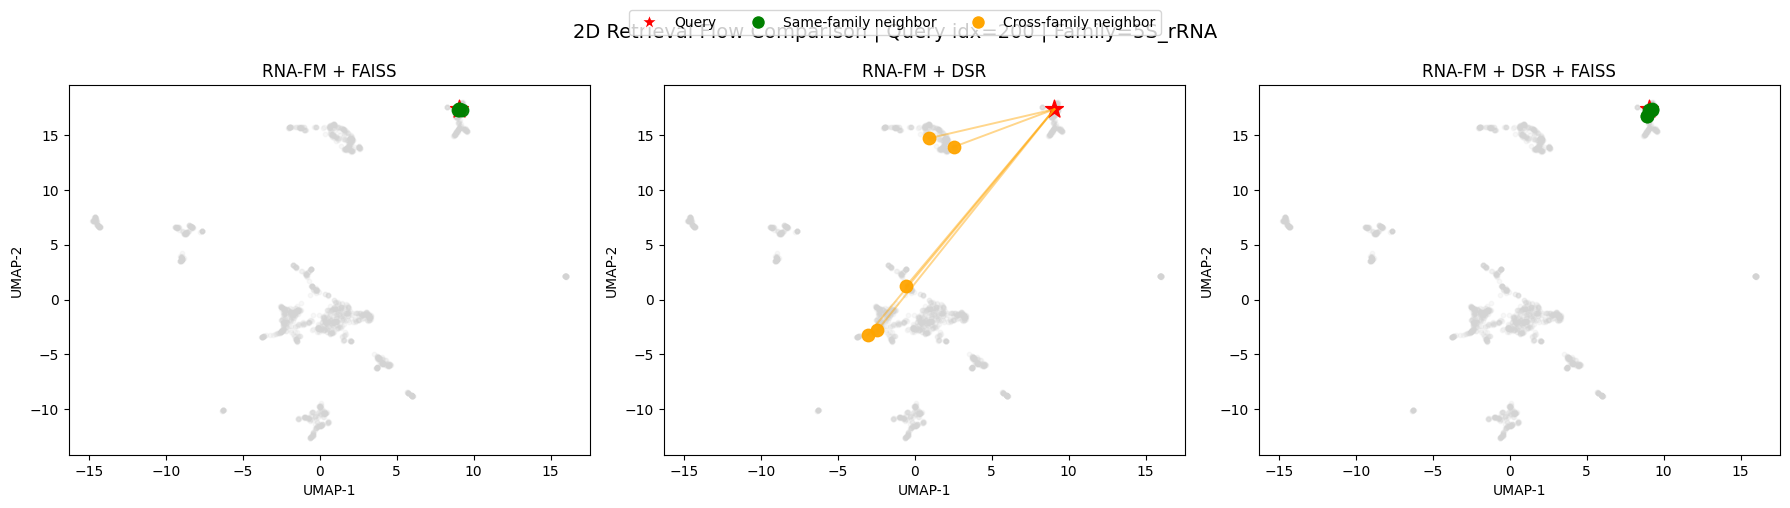

Query family: 5S_rRNA
FAISS neighbors: ['5S_rRNA', '5S_rRNA', '5S_rRNA', '5S_rRNA', '5S_rRNA']
DSR neighbors: ['SRP', 'tRNA', 'SRP', 'tRNA', 'SRP']
Hybrid neighbors: ['5S_rRNA', '5S_rRNA', '5S_rRNA', '5S_rRNA', '5S_rRNA']
Saved: results/plots/case_studies/retrieval_flow_best.png


In [97]:
from visualisation.rna_2panel_retrieval_flow import plot_2panel_retrieval_flow

plot_2panel_retrieval_flow(
    query_idx=query_idx,
    k=5,
    save_path="results/plots/case_studies/retrieval_flow_best.png"
)

In [98]:
from data.build_dataset import build_dataset
import pandas as pd

dataset = list(build_dataset())
hyb = pd.read_csv("results/dsr_faiss_hybrid_results.csv")

target_query_id = "SRP-long_bacterial-Clos.ther._CP000568"   # or whatever appears in your CSV
target_family = "SRP"

# first try exact match
query_idx = None
for i, row in enumerate(dataset):
    if str(row["id"]) == str(target_query_id):
        query_idx = i
        break

# fallback: first row from same family
if query_idx is None:
    for i, row in enumerate(dataset):
        if row["family"] == target_family:
            query_idx = i
            break

print("query_idx =", query_idx)
print("matched row =", dataset[query_idx] if query_idx is not None else "not found")

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})
query_idx = 600
matched row = {'id': 'SRP-Legi.pneu._CR628336', 'sequence': 'UUAUUGGUUUCUCGCAGCAGAAUUCAGCUUACUUAGUCAGGGCCGGAAGGAAGCAGCUUGGGUUGAAUUUCUGGGUGCCGGGAGUCGCUGGUAAUACC', 'secondary_structure': '((((((((.((((((..((((((((((((...(.(((.....((....)).....))).)))))))).))))).)...)))))...))))))))....', 'family': 'SRP', 'subfamily': None, 'structure': '((((((((.((((((..((((((((((((...(.(((.....((....)).....))).)))))))).))))).)...)))))...))))))))....'}


In [99]:
from data.build_dataset import build_dataset
import pandas as pd

dataset = list(build_dataset())
hyb = pd.read_csv("results/dsr_faiss_hybrid_results.csv")

target_query_id = "tRNA-tdbD00009470" # or whatever appears in your CSV
target_family = "tRNA"

# first try exact match
query_idx = None
for i, row in enumerate(dataset):
    if str(row["id"]) == str(target_query_id):
        query_idx = i
        break

# fallback: first row from same family
if query_idx is None:
    for i, row in enumerate(dataset):
        if row["family"] == target_family:
            query_idx = i
            break

print("query_idx =", query_idx)
print("matched row =", dataset[query_idx] if query_idx is not None else "not found")

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})
query_idx = 1000
matched row = {'id': 'tRNA-tdbD00007884', 'sequence': 'GUCUCUGUGGCGCAAUUGGGUUAGCGCGUUCGGUUGUUAACCGUAAAGGUUGGUGGUUCGAGCCCACCCAGGAAC', 'secondary_structure': '((.((((..((((..........)))).(.(((.......))).)......(((((.......))))))))).))', 'family': 'tRNA', 'subfamily': None, 'structure': '((.((((..((((..........)))).(.(((.......))).)......(((((.......))))))))).))'}


Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



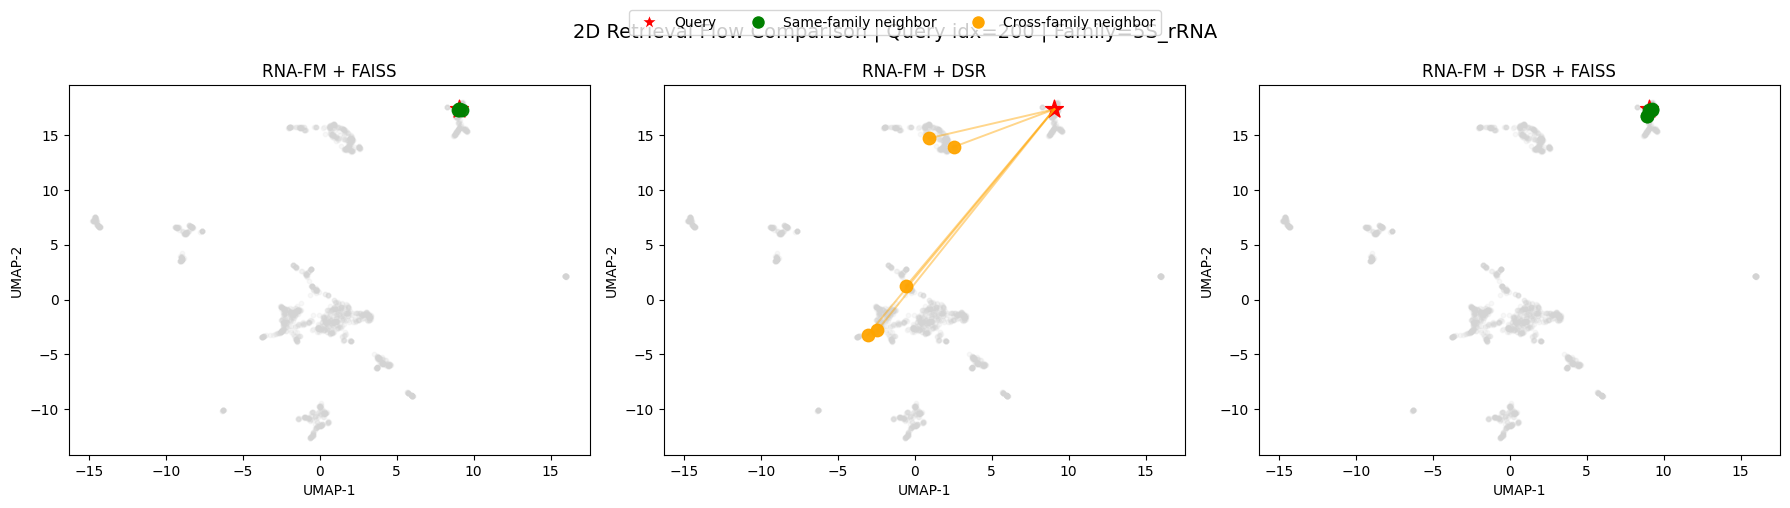

Query family: 5S_rRNA
FAISS neighbors: ['5S_rRNA', '5S_rRNA', '5S_rRNA', '5S_rRNA', '5S_rRNA']
DSR neighbors: ['SRP', 'tRNA', 'SRP', 'tRNA', 'SRP']
Hybrid neighbors: ['5S_rRNA', '5S_rRNA', '5S_rRNA', '5S_rRNA', '5S_rRNA']
Saved: results/plots/case_studies/retrieval_flow_best.png
Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



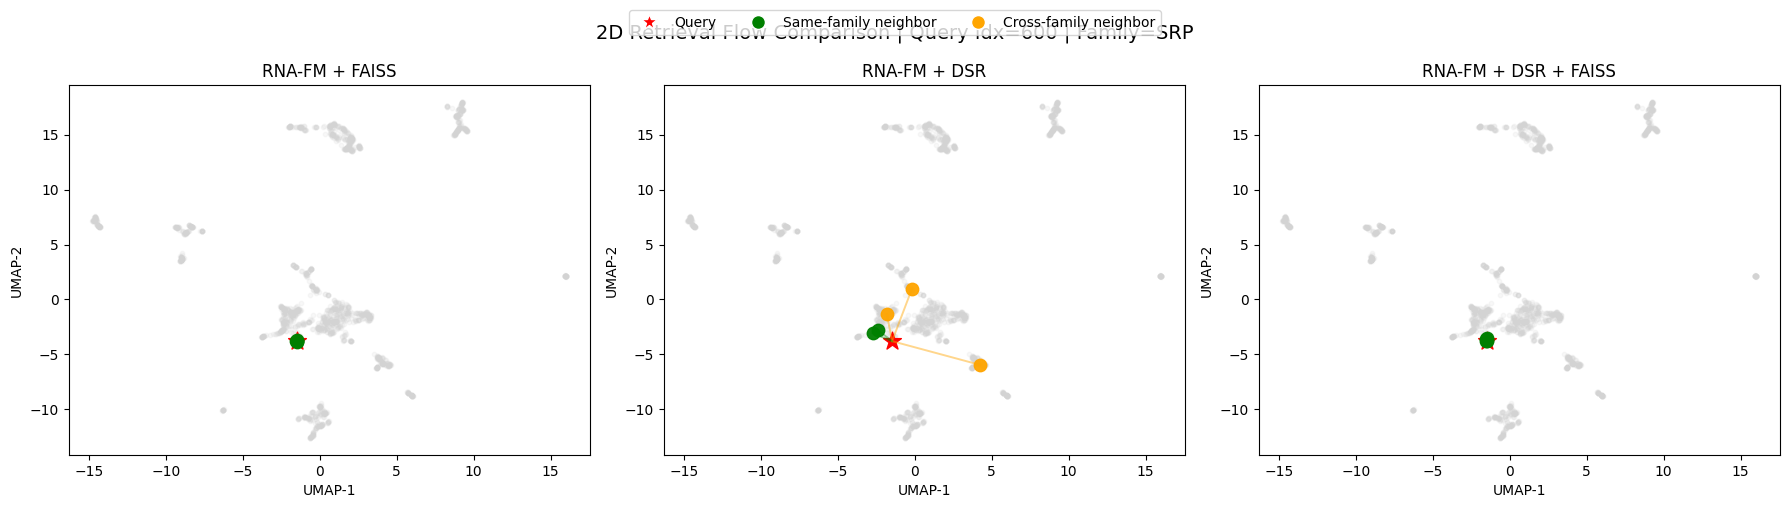

Query family: SRP
FAISS neighbors: ['SRP', 'SRP', 'SRP', 'SRP', 'SRP']
DSR neighbors: ['SRP', 'RNaseP', 'RfamFamily', 'RNaseP', 'SRP']
Hybrid neighbors: ['SRP', 'SRP', 'SRP', 'SRP', 'SRP']
Saved: results/plots/case_studies/retrieval_flow_typical.png
Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



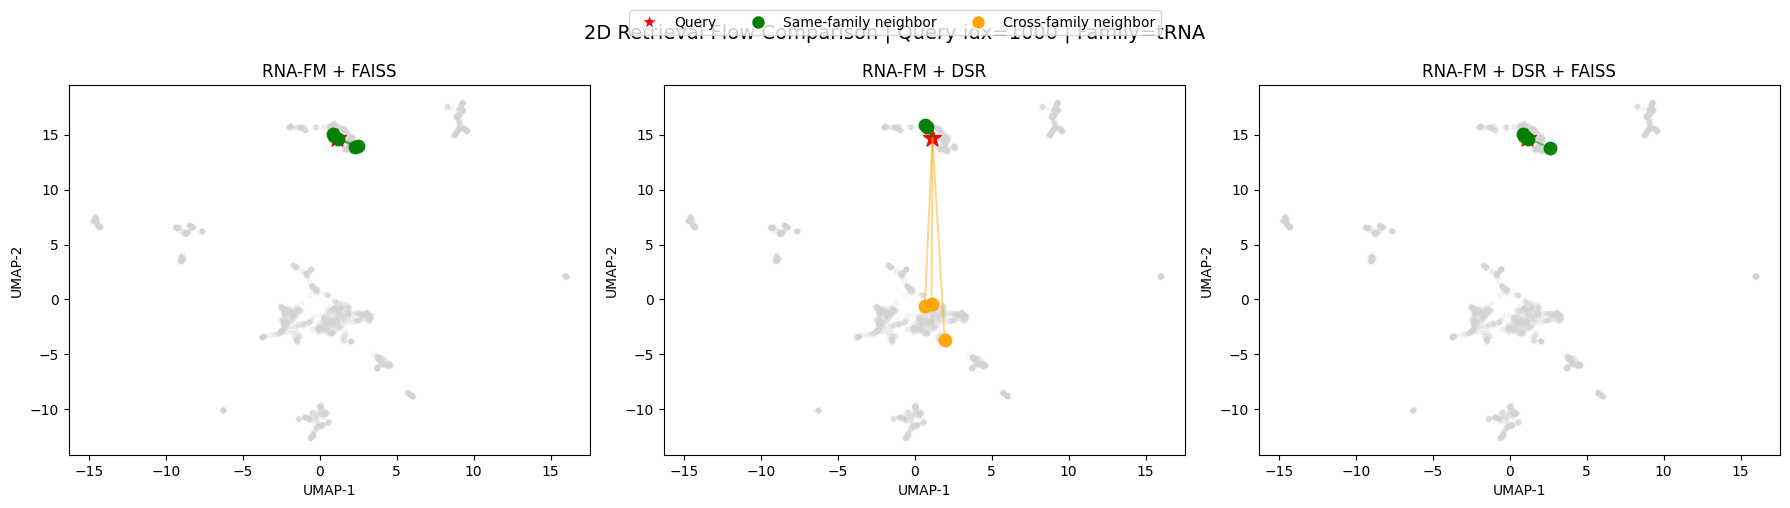

Query family: tRNA
FAISS neighbors: ['tRNA', 'tRNA', 'tRNA', 'tRNA', 'tRNA']
DSR neighbors: ['RfamFamily', 'tRNA', 'RNaseP', 'SRP', 'tRNA']
Hybrid neighbors: ['tRNA', 'tRNA', 'tRNA', 'tRNA', 'tRNA']
Saved: results/plots/case_studies/retrieval_flow_worst.png


In [100]:
from visualisation.rna_2panel_retrieval_flow import plot_2panel_retrieval_flow

plot_2panel_retrieval_flow(query_idx=200, k=5,
    save_path="results/plots/case_studies/retrieval_flow_best.png")

plot_2panel_retrieval_flow(query_idx=600, k=5,
    save_path="results/plots/case_studies/retrieval_flow_typical.png")

plot_2panel_retrieval_flow(query_idx=1000, k=5,
    save_path="results/plots/case_studies/retrieval_flow_worst.png")

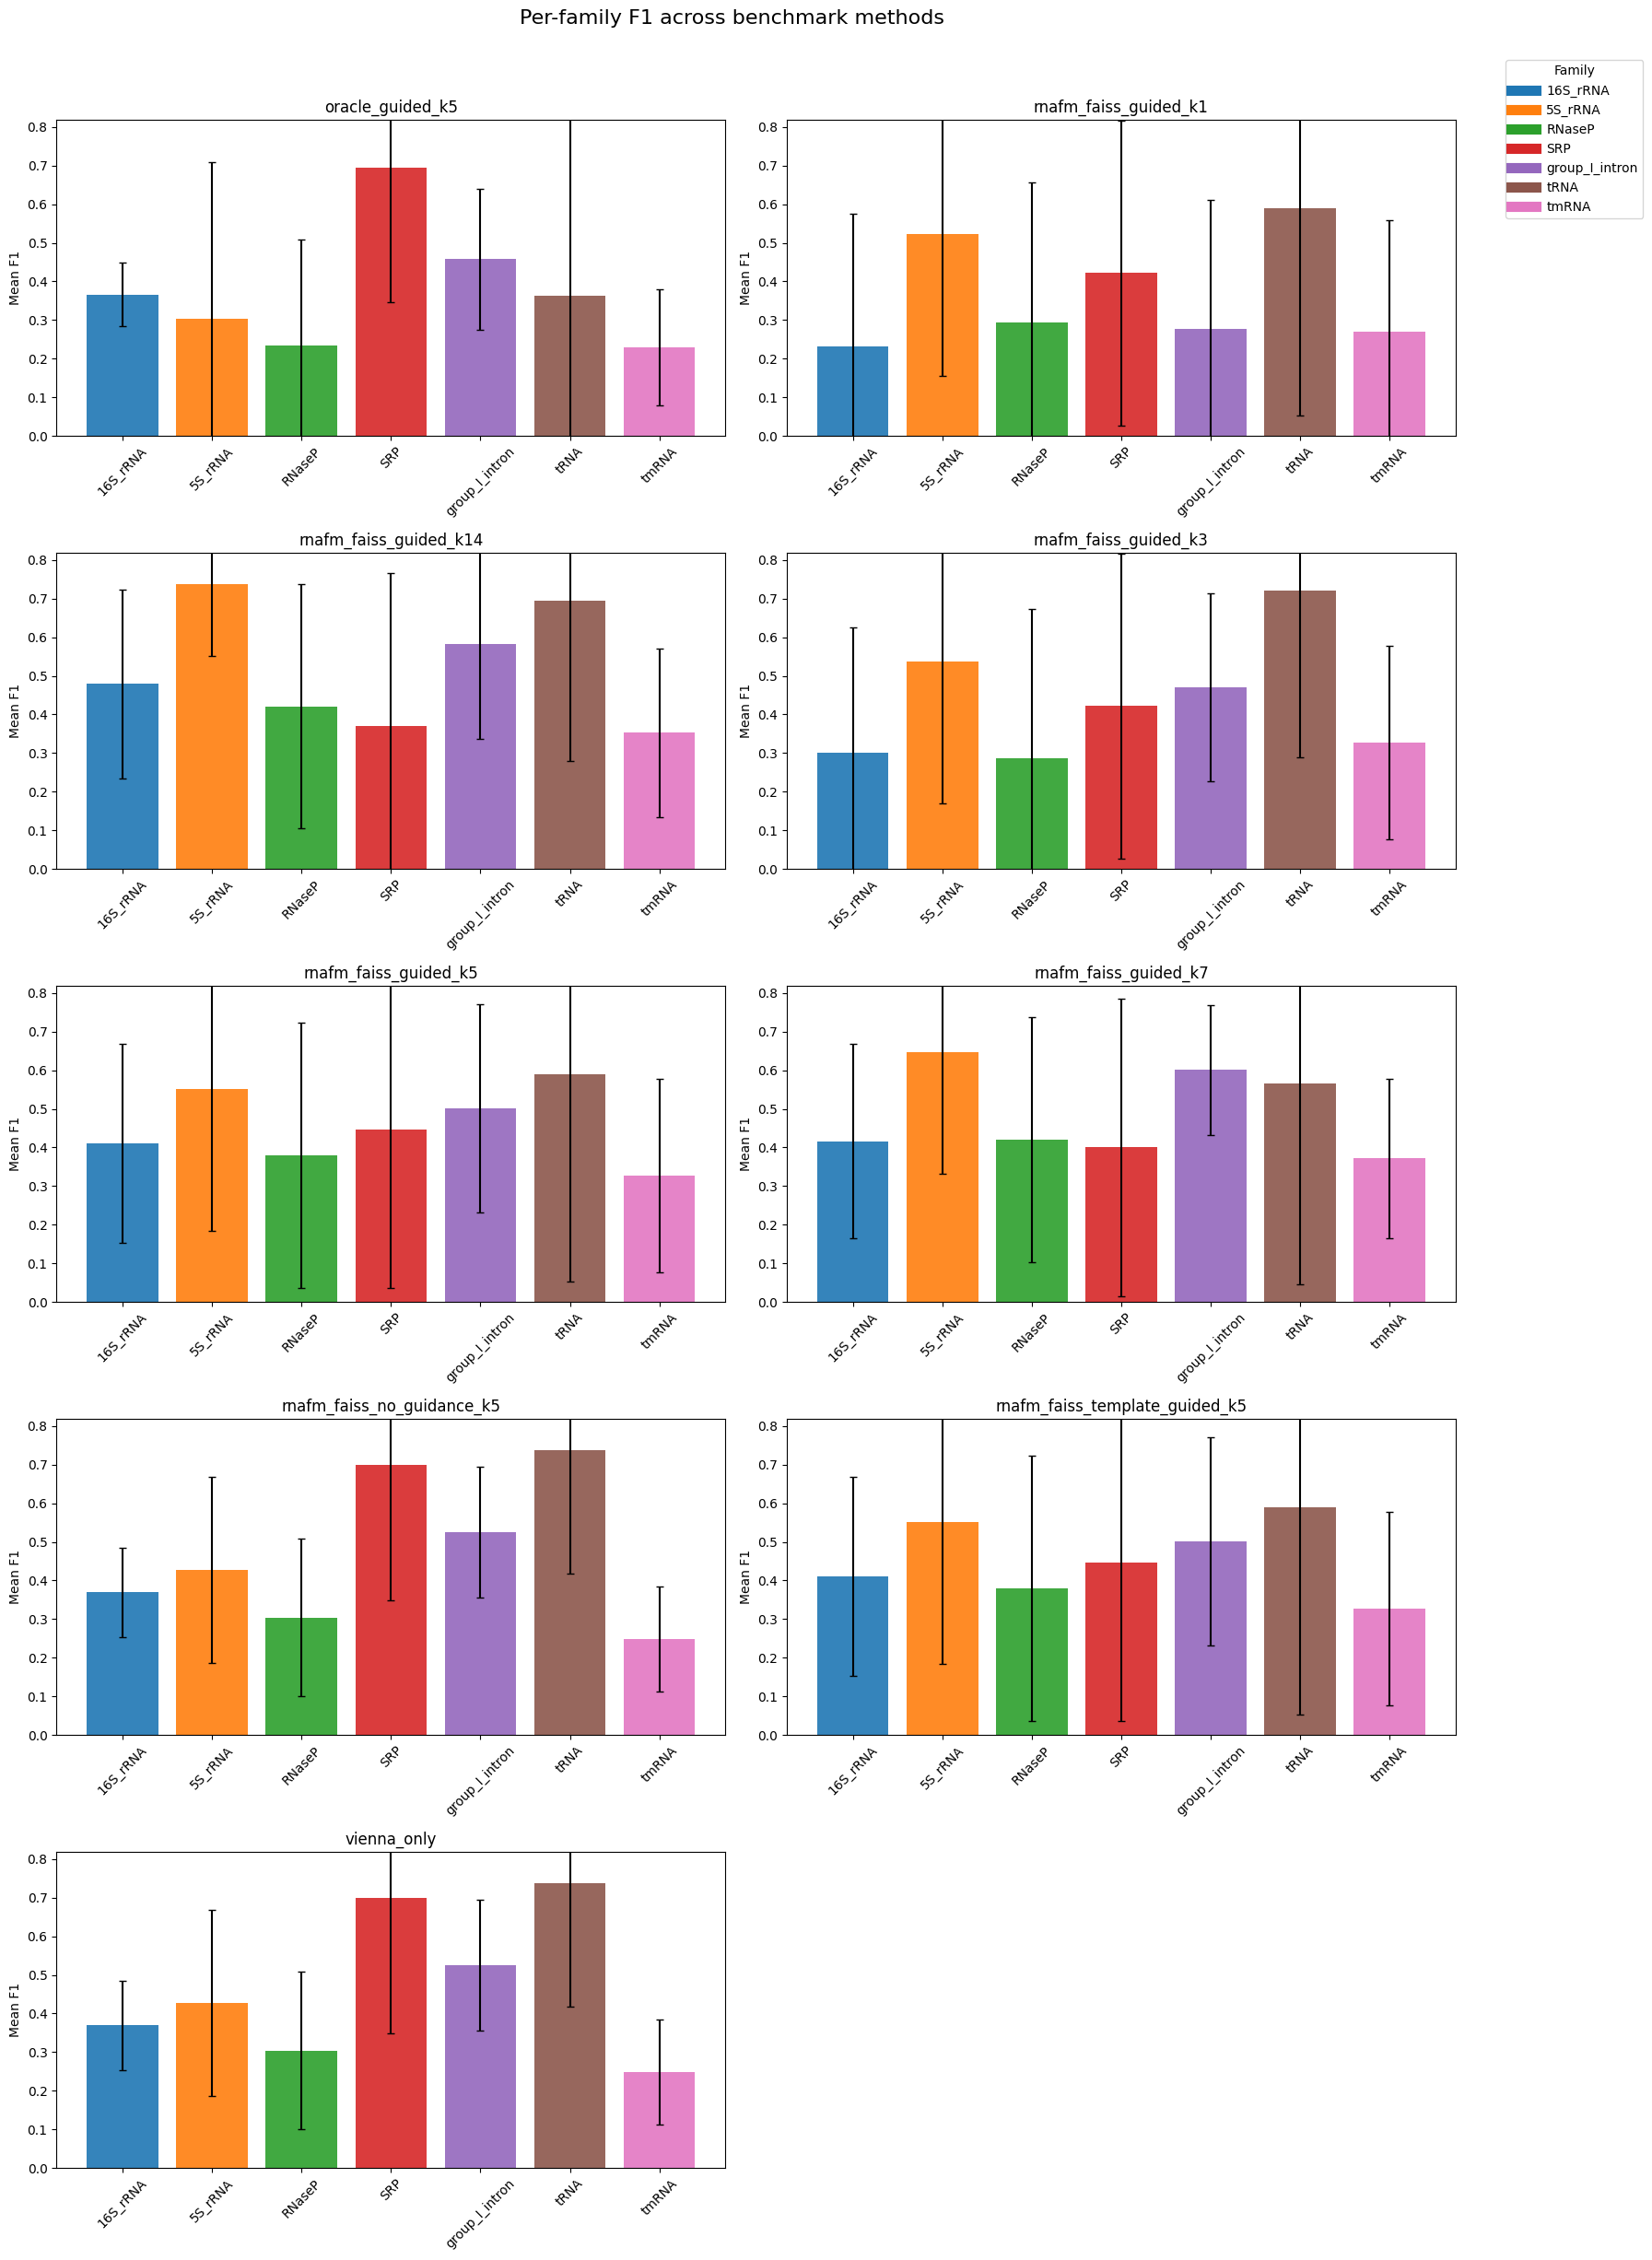

In [101]:
from visualisation.family_benchmark_panel import plot_family_benchmark_panel

plot_family_benchmark_panel(
    csv_path="results/ablation_results.csv",
    exclude_families=["RfamFamily"],   # optional
    save_path="results/plots/family_benchmark_panel.png",
)

In [102]:
import pandas as pd

bench = pd.read_csv("results/benchmark_main.csv")
ab = pd.read_csv("results/ablation_results.csv")
dsr = pd.read_csv("results/dsr_global_all_results.csv")
hyb = pd.read_csv("results/dsr_faiss_hybrid_results.csv")

vienna = bench[bench["method"] == "vienna_only"].copy()
faiss = ab[ab["method"] == "rnafm_faiss_guided_k14"].copy()
dsr = dsr[dsr["method"] == "rnafm_dsr_global_guided_k14"].copy()
hyb = hyb[hyb["method"] == "rnafm_dsr_faiss_guided_k14"].copy()

combined = pd.concat([vienna, faiss, dsr, hyb], ignore_index=True)
combined.to_csv("results/final_family_benchmark_methods.csv", index=False)

print(combined["method"].value_counts())

method
rnafm_dsr_faiss_guided_k14     1600
rnafm_dsr_global_guided_k14    1600
rnafm_faiss_guided_k14           50
vienna_only                      50
Name: count, dtype: int64


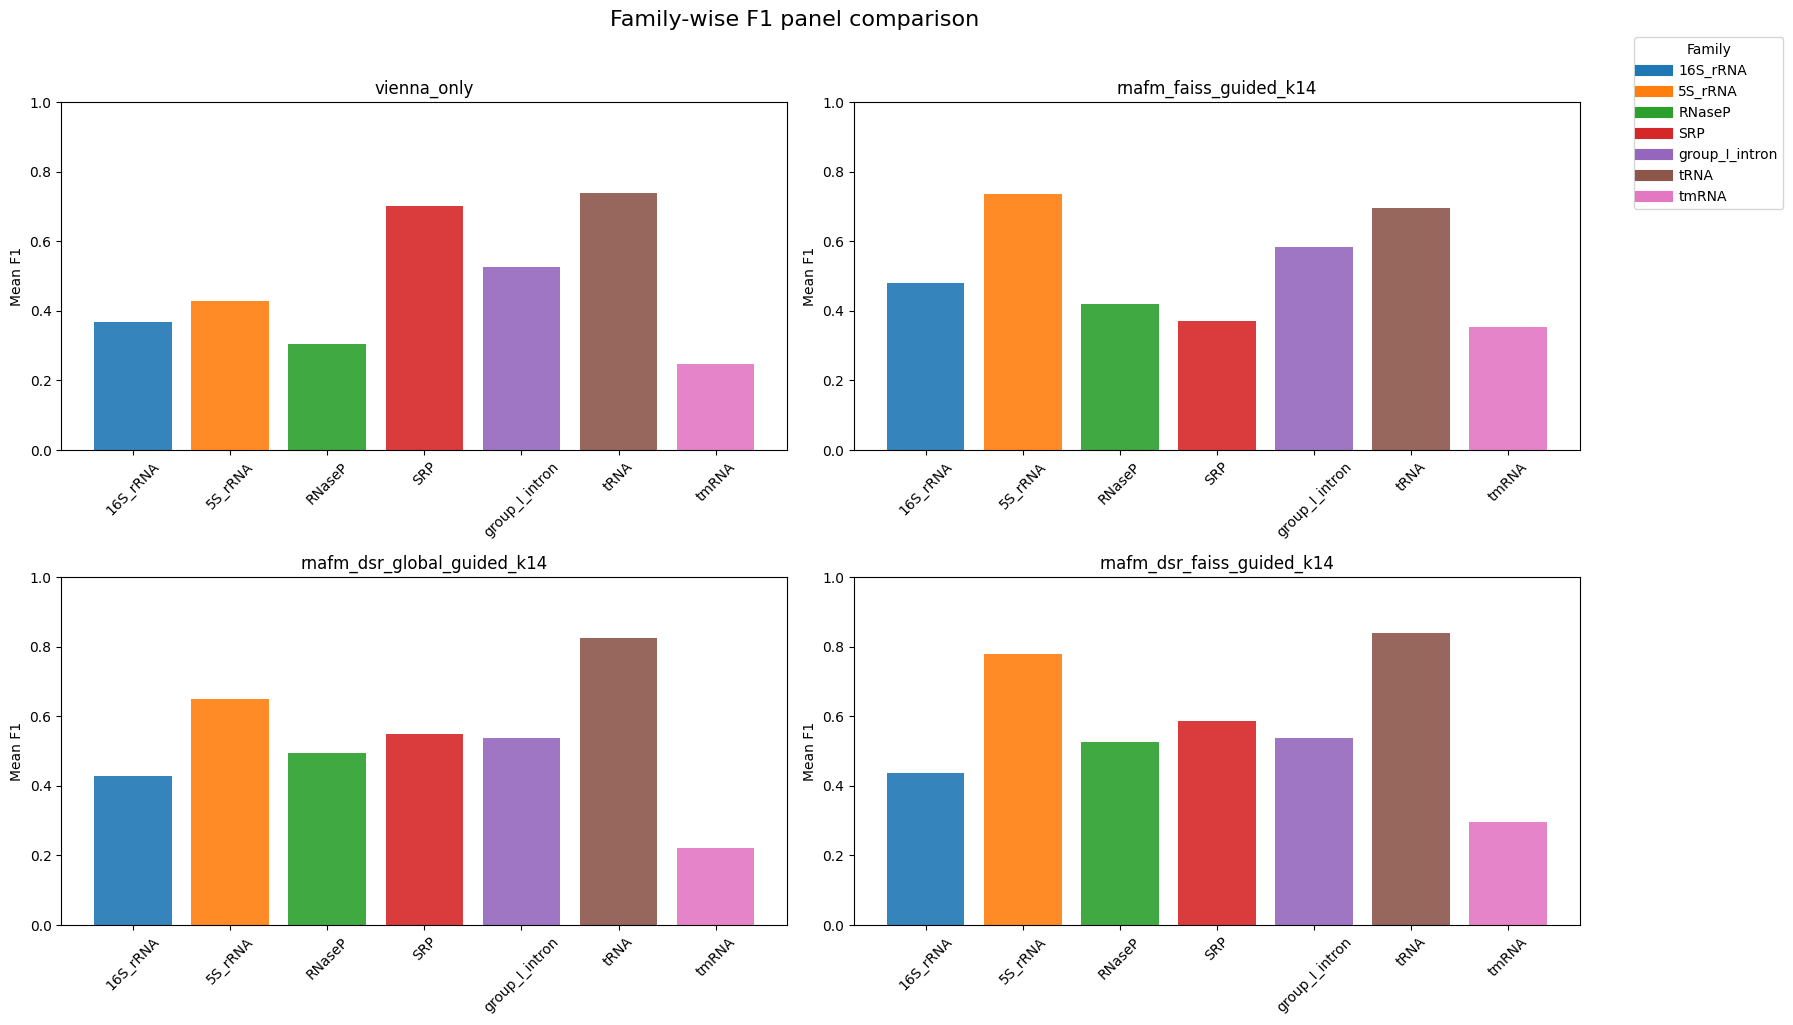

In [104]:
from visualisation.family_benchmark_panel import plot_family_benchmark_panel_compact

plot_family_benchmark_panel_compact(
    csv_path="results/final_family_benchmark_methods.csv",
    exclude_families=["RfamFamily"],   # optional
    save_path="results/plots/final_family_benchmark_panel.png",
)

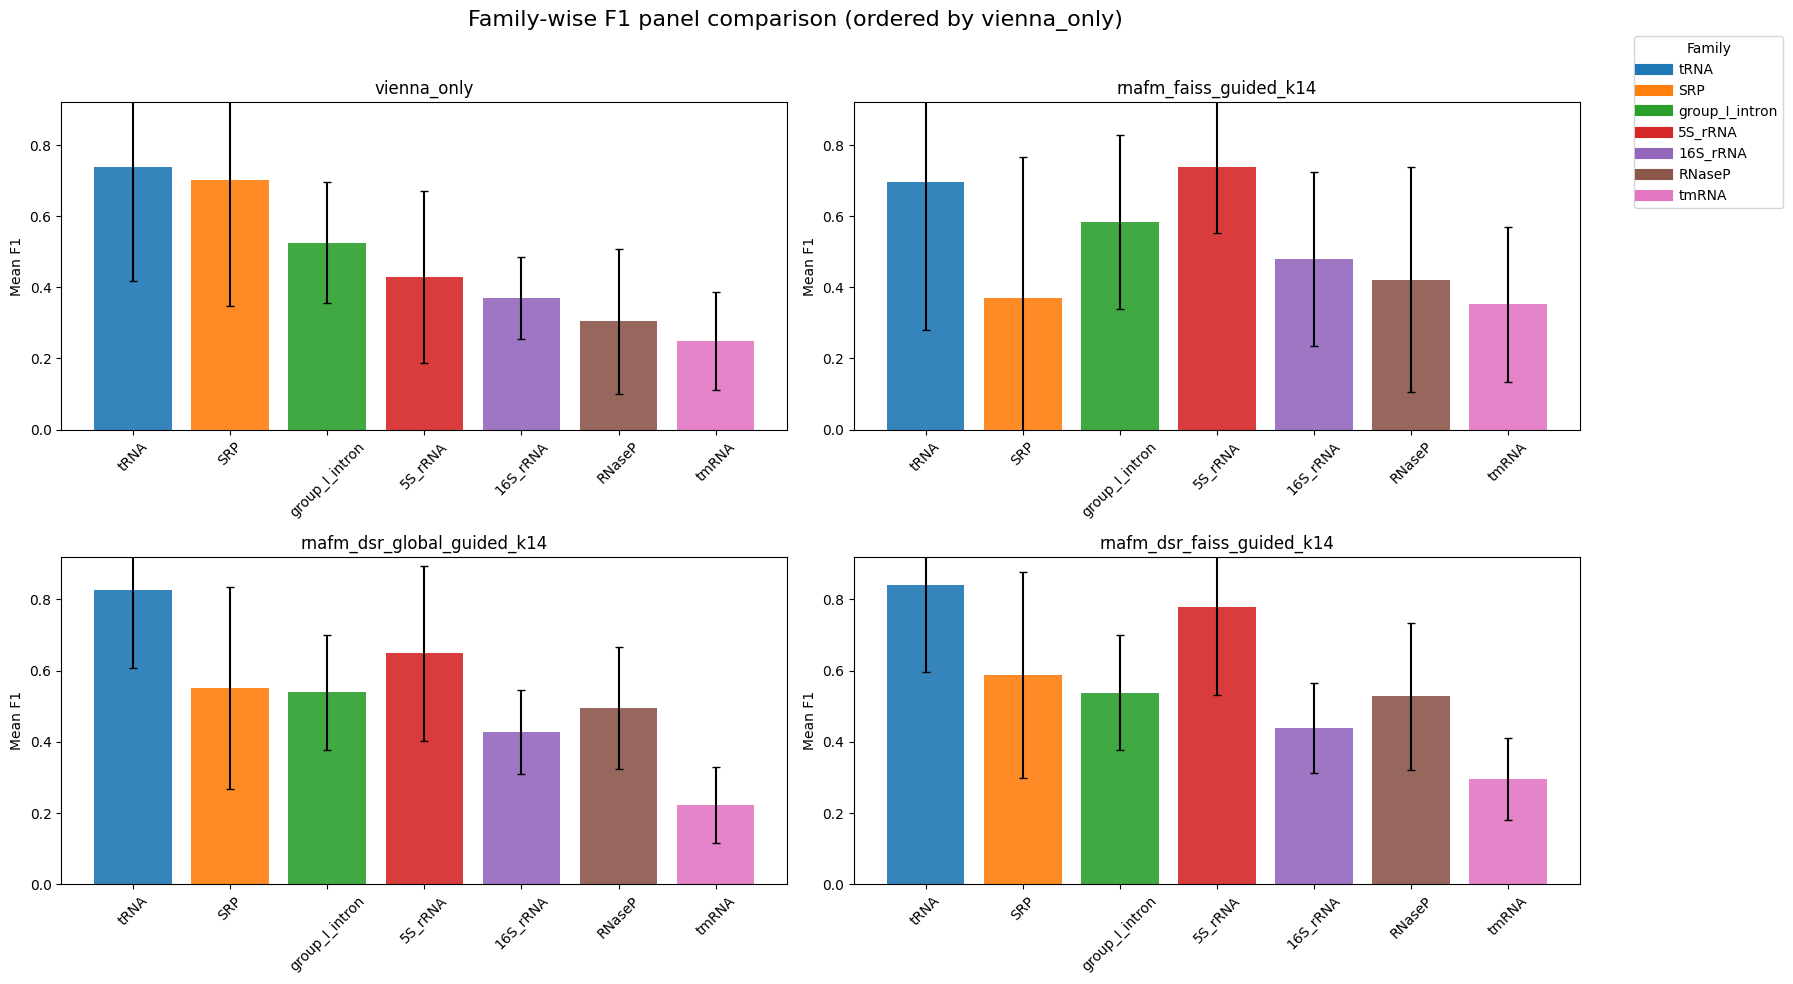

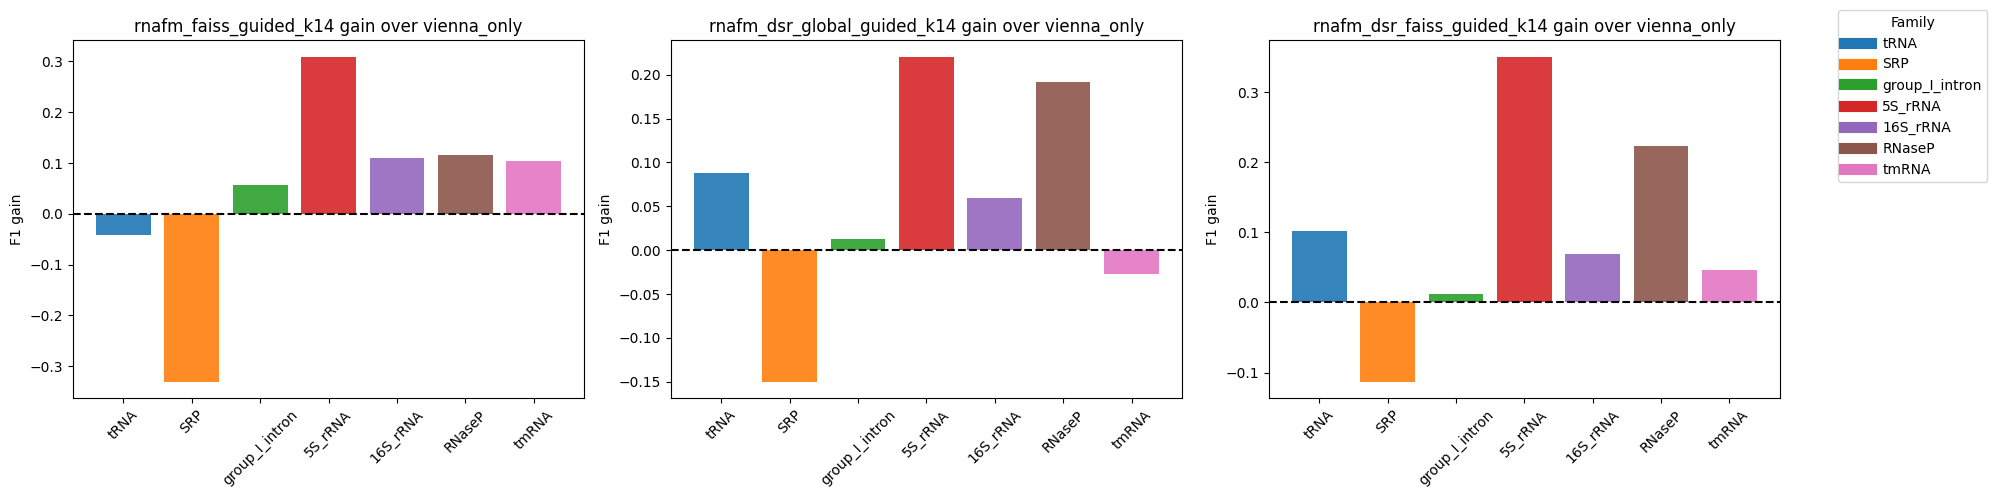

In [109]:
import importlib
import visualisation.family_benchmark_panel as fb

importlib.reload(fb)
fb.plot_family_benchmark_panel_ordered(
    csv_path="results/final_family_benchmark_methods.csv",
    order_by="vienna_only",
    exclude_families=["RfamFamily"],
    save_path="results/plots/final_family_benchmark_panel_ordered.png",
)

fb.plot_family_gain_panel(
    csv_path="results/final_family_benchmark_methods.csv",
    exclude_families=["RfamFamily"],
    save_path="results/plots/family_gain_panel.png",
)

/content/drive/MyDrive/Foldv/visualisation/final_eccb_figure.py:68: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




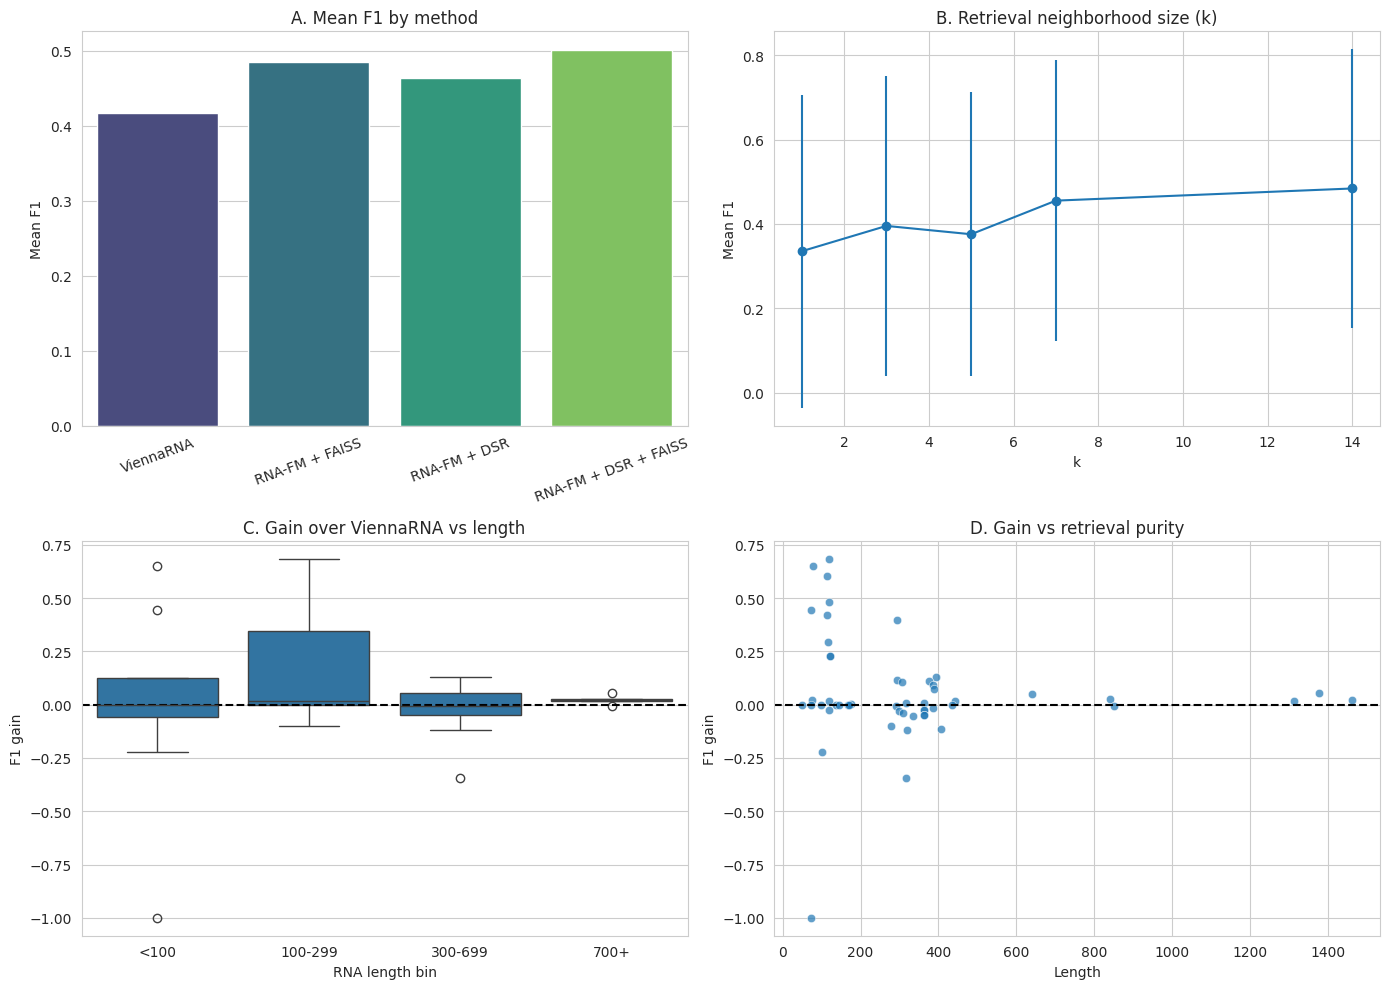

Saved: results/plots/final_eccb_figure.png


In [110]:
from visualisation.final_eccb_figure import plot_final_eccb_figure
plot_final_eccb_figure()

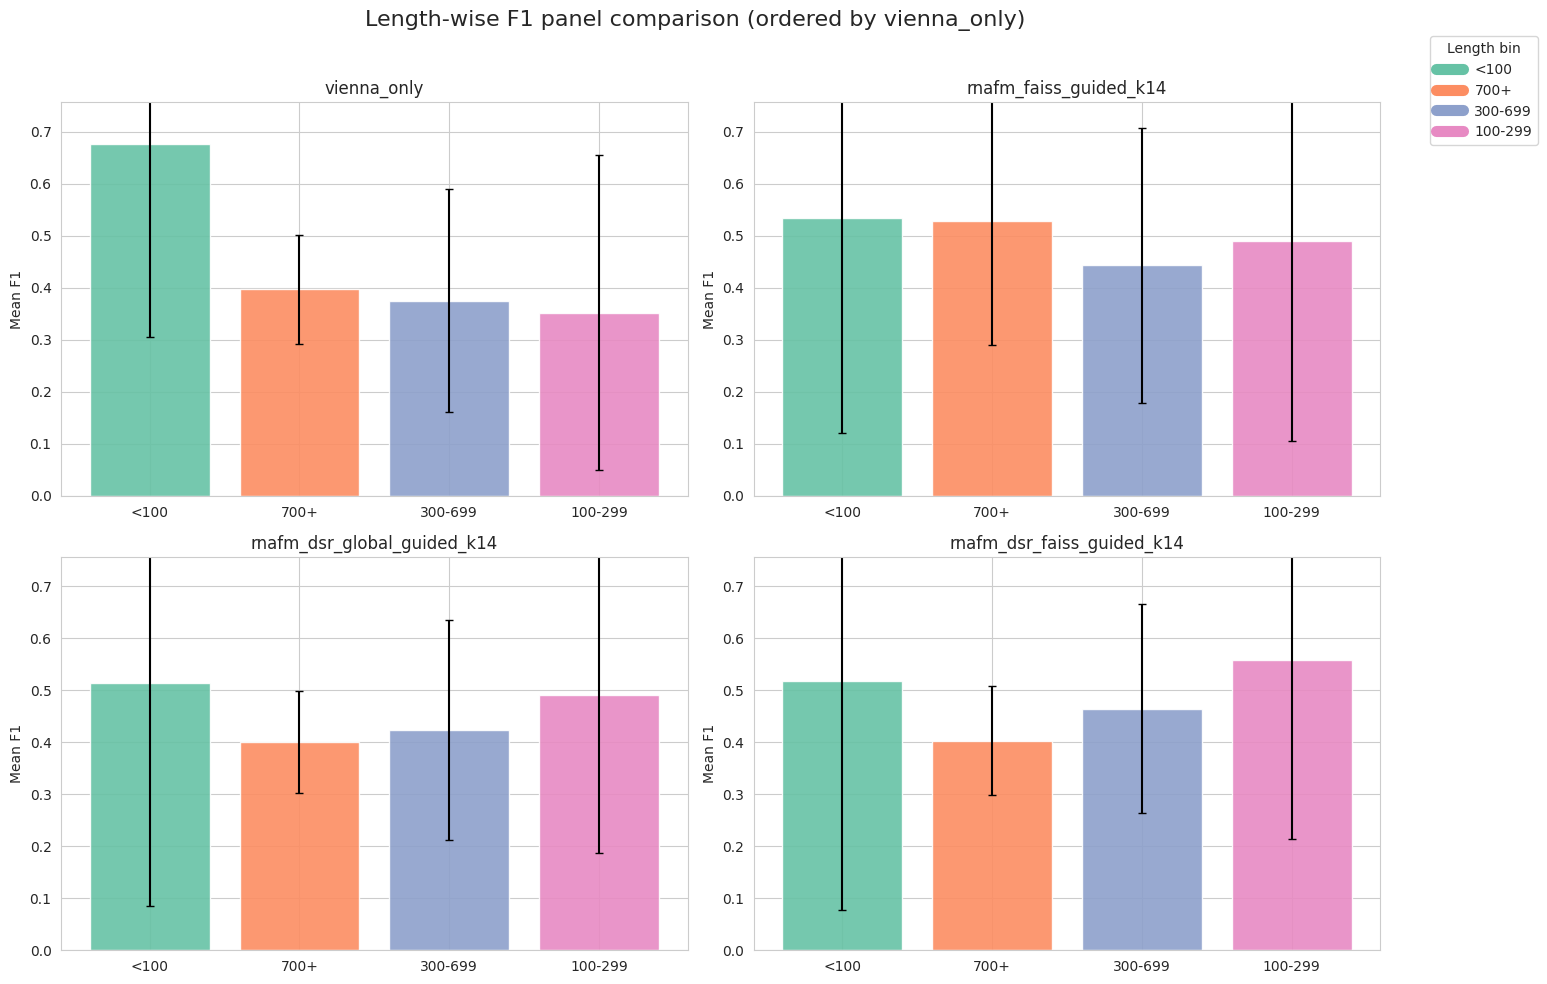

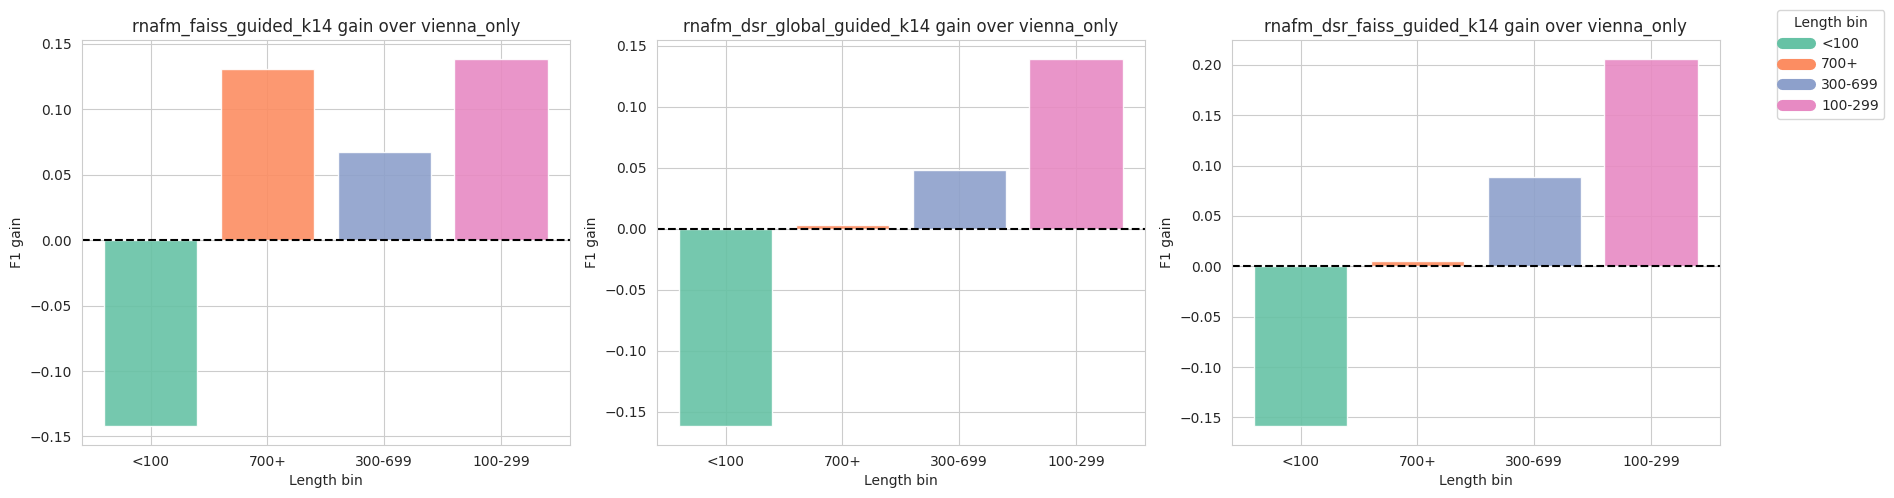

In [111]:
import importlib
import visualisation.length_benchmark_panel as lbp
importlib.reload(lbp)

lbp.plot_length_benchmark_panel_ordered(
    csv_path="results/final_family_benchmark_methods.csv",
    order_by="vienna_only",
    save_path="results/plots/final_length_benchmark_panel_ordered.png",
)

lbp.plot_length_gain_panel(
    csv_path="results/final_family_benchmark_methods.csv",
    save_path="results/plots/length_gain_panel.png",
)

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


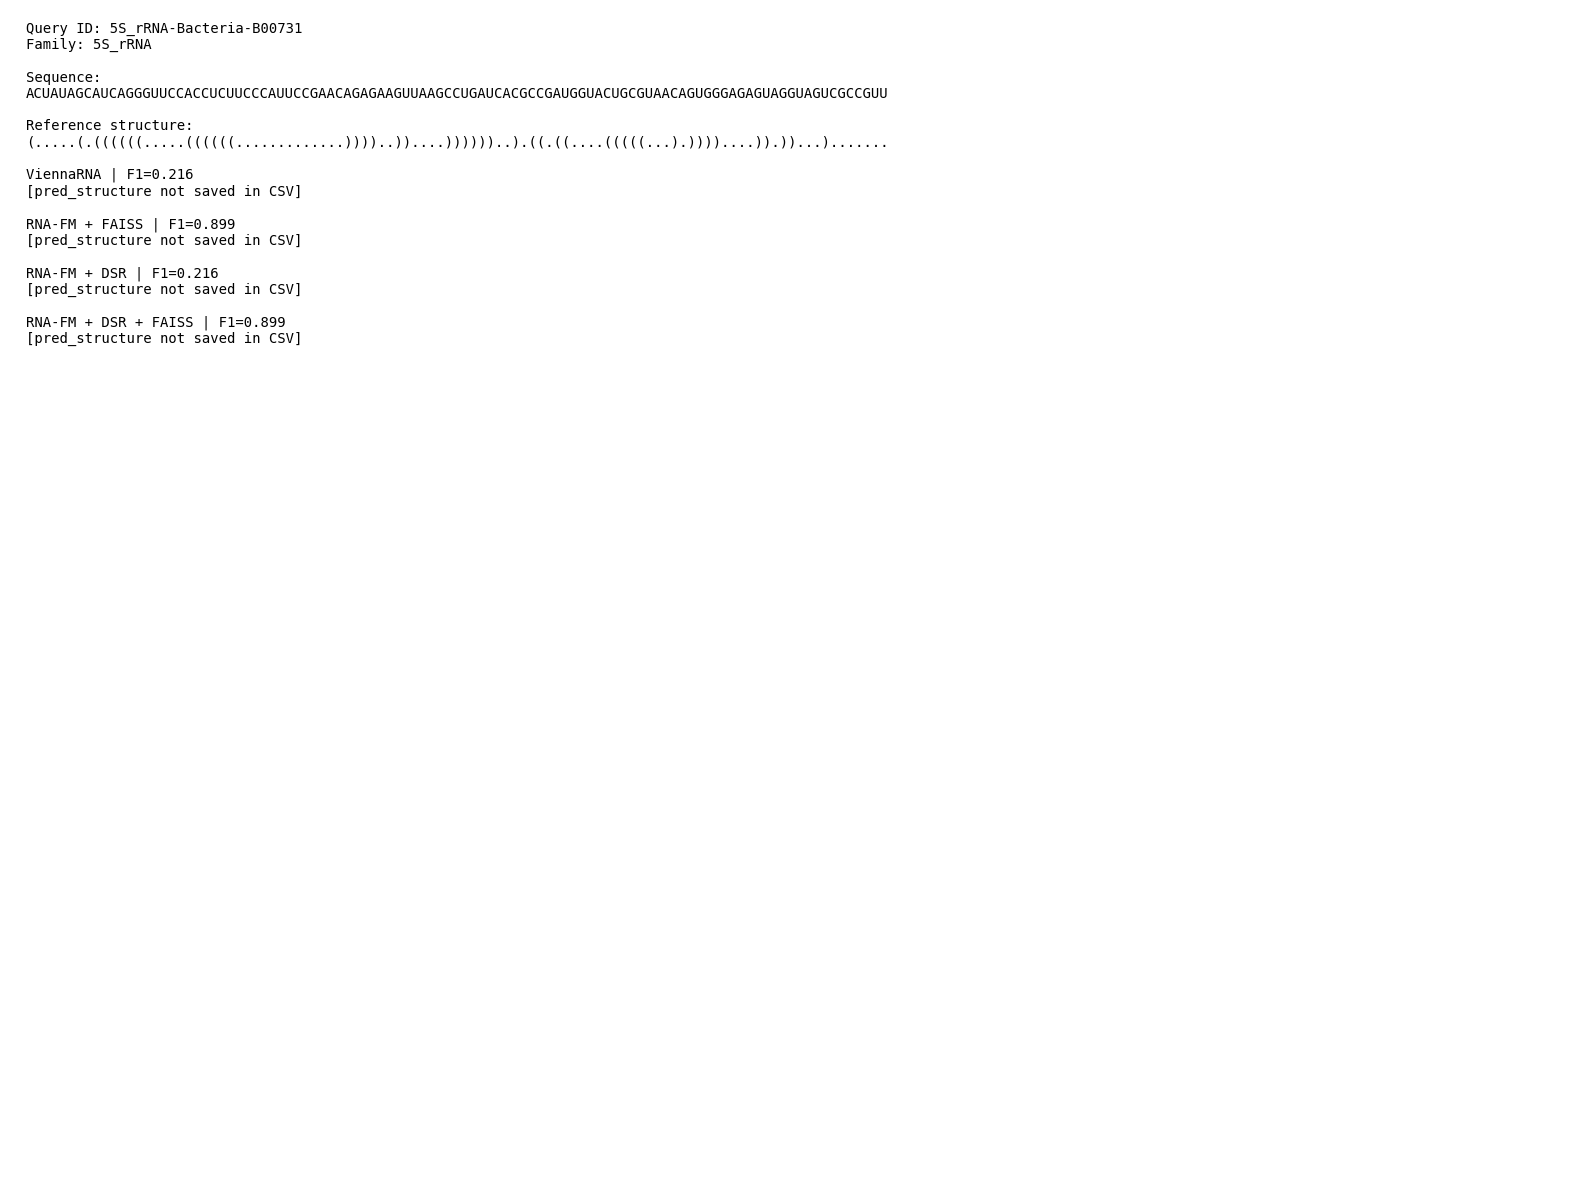

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


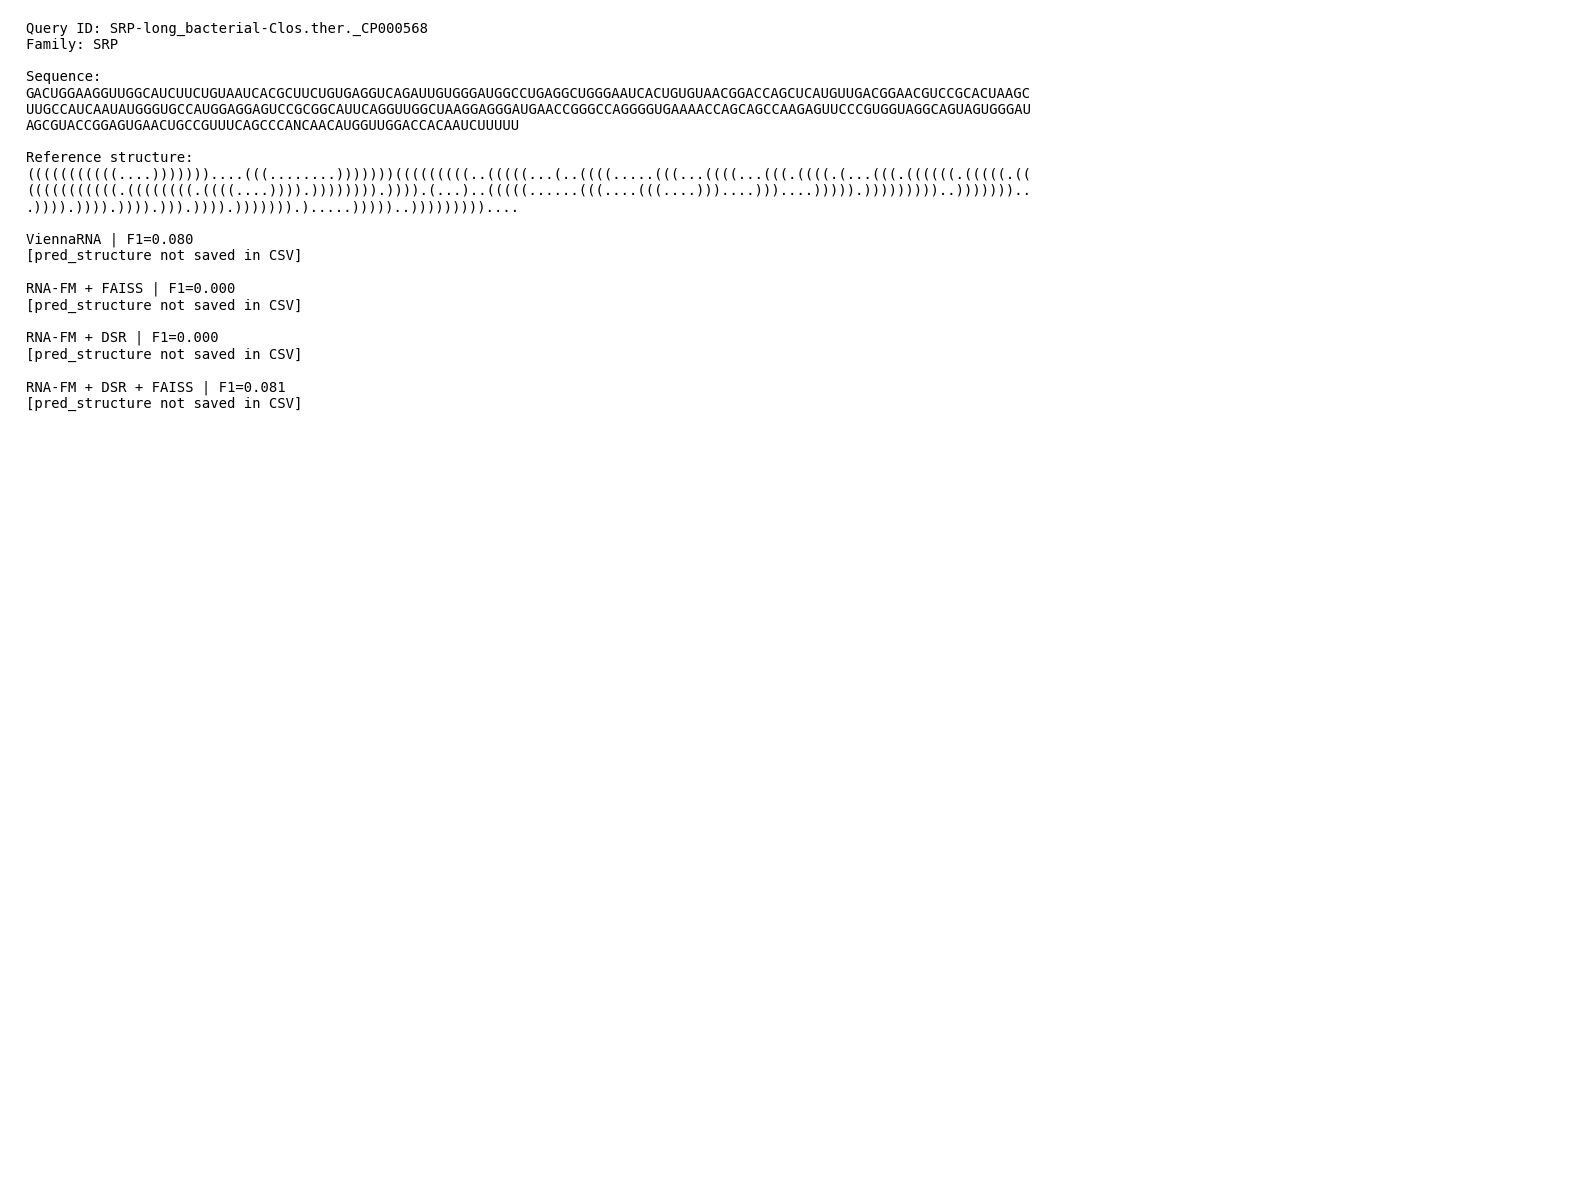

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


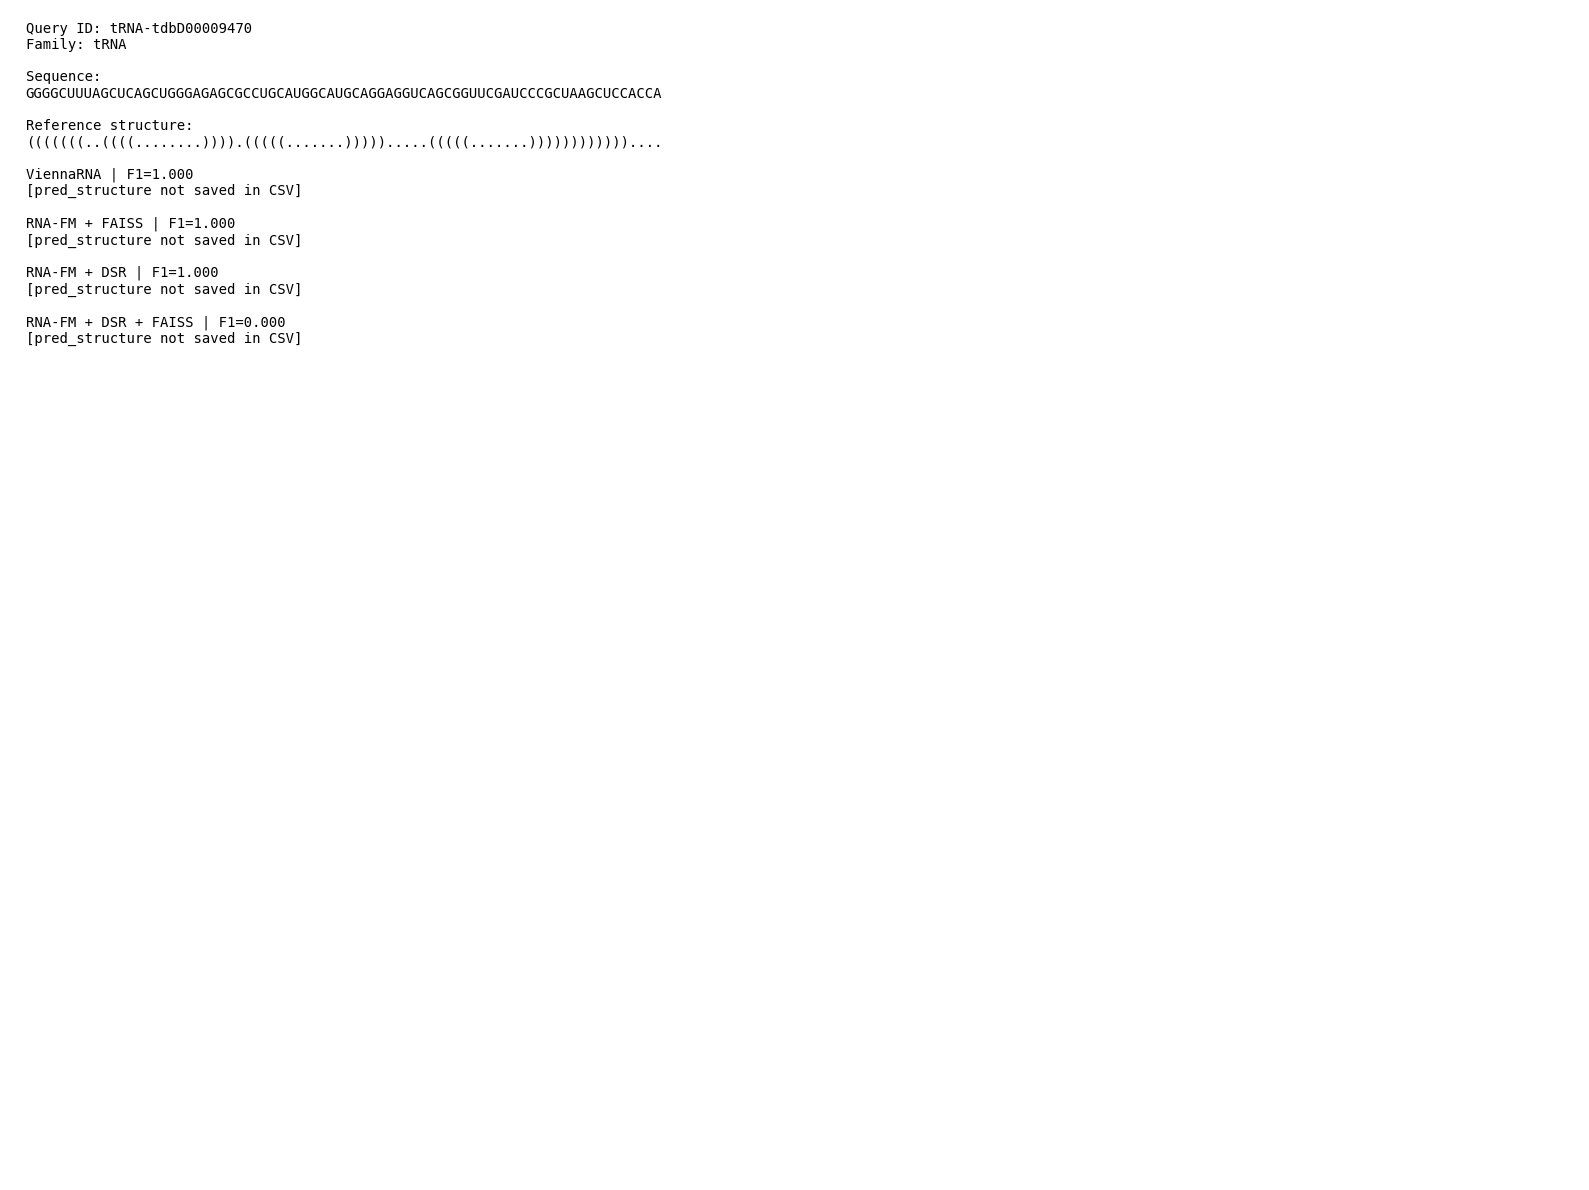

In [ ]:
import importlib
import visualisation.side_by_side_case_viz as ssv
importlib.reload(ssv)

ssv.plot_side_by_side_case(
    query_id="5S_rRNA-Bacteria-B00731",
    save_path="results/plots/case_studies/side_by_side_best.png"
)

ssv.plot_side_by_side_case(
    query_id="SRP-long_bacterial-Clos.ther._CP000568",
    save_path="results/plots/case_studies/side_by_side_typical.png"
)

ssv.plot_side_by_side_case(
    query_id="tRNA-tdbD00009470",
    save_path="results/plots/case_studies/side_by_side_worst.png"
)

       rna_family  baseline_n  baseline_f1  baseline_sensitivity  \
0        16S_rRNA           6     0.369366              0.389384   
1         5S_rRNA           9     0.428223              0.453059   
2          RNaseP           7     0.304335              0.329567   
3      RfamFamily           5     0.000000              0.000000   
4             SRP           5     0.700692              0.721926   
5  group_I_intron           8     0.525668              0.543918   
6            tRNA           5     0.738168              0.767619   
7           tmRNA           5     0.248734              0.256314   

   baseline_ppv  lofo_n   lofo_f1  lofo_sensitivity  lofo_ppv  transfer_gain  
0      0.351721     200  0.395998          0.403445  0.391007       0.026632  
1      0.406311     200  0.299902          0.281816  0.331992      -0.128320  
2      0.285876     200  0.464499          0.490573  0.453507       0.160165  
3      0.000000     200  0.000000          0.000000  0.000000       0.0

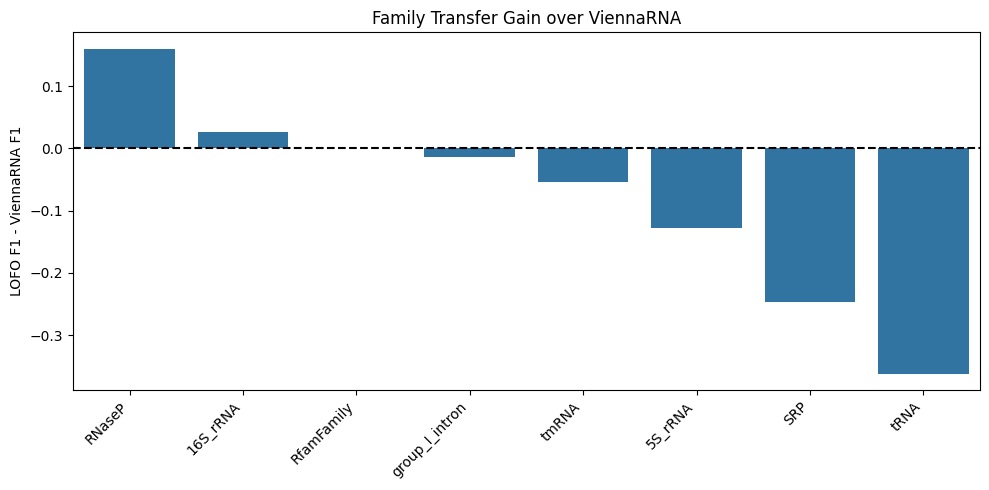

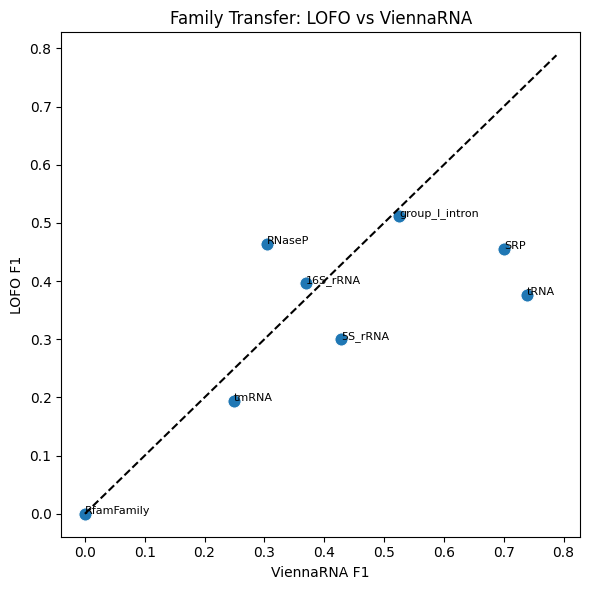

In [ ]:
from evaluation.family_transfer import compute_family_transfer
from visualisation.family_transfer_plots import (
    plot_family_transfer_gain,
    plot_family_transfer_scatter,
)

df_transfer = compute_family_transfer()
print(df_transfer)

plot_family_transfer_gain()
plot_family_transfer_scatter()

In [ ]:
import importlib
import visualisation.dsr_global_plots as dsrplots
importlib.reload(dsrplots)

<module 'visualisation.dsr_global_plots' from '/content/drive/MyDrive/Foldv/visualisation/dsr_global_plots.py'>

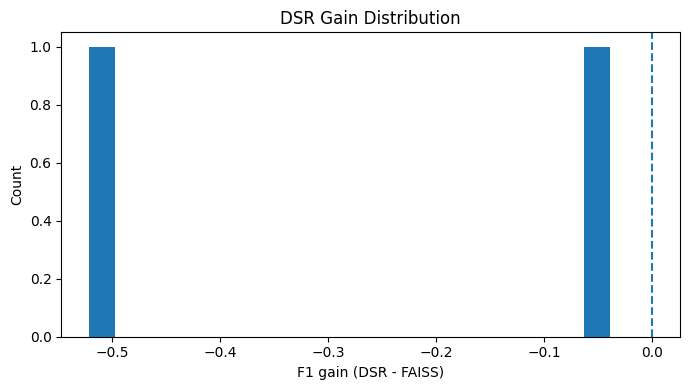

In [ ]:
from visualisation.dsr_global_plots import plot_dsr_gain_distribution
plot_dsr_gain_distribution()